In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy.io import loadmat 
import glob
#from natsort import natsorted
# from impedance.models.circuits import CustomCircuit
# from impedance import preprocessing
# from impedance.validation import linKK
from pathlib import Path
import matplotlib.pylab as pl
from matplotlib import colors
pd.options.mode.chained_assignment = None  # default='warn'
%matplotlib widget


import rwth_colors
from cycler import cycler
import matplotlib as mpl

rwth_colors_cycler_color = [
    rwth_colors.colors[('blue', 100)],
    rwth_colors.colors[('black', 100)],
    rwth_colors.colors[('magenta', 100)],
    rwth_colors.colors[('yellow', 100)],
    rwth_colors.colors[('green', 100)],
    rwth_colors.colors[('bordeaux', 100)],
    rwth_colors.colors[('orange', 100)],
    rwth_colors.colors[('turqoise', 100)],
    rwth_colors.colors[('darkred', 100)],
    rwth_colors.colors[('lime', 100)],
    rwth_colors.colors[('petrol', 100)],
    rwth_colors.colors[('lavender', 100)],
    rwth_colors.colors[('red', 100)],

    rwth_colors.colors[('blue', 50)],
    rwth_colors.colors[('black', 50)],
    rwth_colors.colors[('magenta', 50)],
    rwth_colors.colors[('yellow', 50)],
    rwth_colors.colors[('green', 50)],
    rwth_colors.colors[('bordeaux', 50)],
    rwth_colors.colors[('orange', 50)],
    rwth_colors.colors[('turqoise', 50)],
    rwth_colors.colors[('darkred', 50)],
    rwth_colors.colors[('lime', 50)],
    rwth_colors.colors[('petrol', 50)],
    rwth_colors.colors[('lavender', 50)],
    rwth_colors.colors[('red', 50)]
]

rwth_colors_cycler_linestyle = [
    '-',
    '--',
    '-.'
]

cc = (cycler(linestyle=rwth_colors_cycler_linestyle)
      * cycler(color=rwth_colors_cycler_color))

mpl.rcParams['axes.prop_cycle'] = cc
mpl.rcParams['axes.facecolor'] = 'none'
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['axes.titlesize'] = 11
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['font.size'] = 11
mpl.rcParams['image.cmap'] = 'turbo'
mpl.rcParams['xtick.labelsize'] = 11
mpl.rcParams['ytick.labelsize'] = 11
mpl.rcParams['legend.fontsize'] = 11

In [3]:
def Compare_CU_csv_shift (path):
    files={}
    dataset_number = []
    df_List = []
    cellpath = []
    df_dict ={}
    rootpath = path

    List_Cell = glob.glob1(rootpath, '*.csv')
    for cell in List_Cell:
        fullpath = rootpath + '/' + cell
        cellpath.append(fullpath)


    for cell_file in cellpath:
        df_read = pd.read_csv(cell_file,sep = ',',
                              low_memory=False,
                              usecols = ['Spannung','Strom','AhAkku','Programmdauer'])
        df_read1 = df_read[1:]
        df_read1['Spannung']=df_read1['Spannung'].convert_dtypes().astype(float)
        df_read1['Strom']=df_read1['Strom'].convert_dtypes().astype(float)
        df_read1['AhAkku']=df_read1['AhAkku'].convert_dtypes().astype(float)
        df_read1['Programmdauer']=df_read1['Programmdauer']/3600000
        df_read1['Name'] = cell_file.split('_')[2]

        df_List.append(df_read1.round(4))

    # Shift so the first peaks overlay
    df_List_shifted = []

    reference = df_List[0][(df_List[0]['Spannung']>= 3.5999)].Programmdauer.index[0]
    df_List_shifted.append(df_List[0])

    for cell_df in df_List[1:]:
        offset = reference - cell_df[cell_df['Spannung']>=  3.5999].Programmdauer.index[0]
        mask = ~(cell_df.columns.isin(['Programmdauer','Name']))
        cols_to_shift = cell_df.columns[mask]
        cell_df[cols_to_shift] = cell_df[cols_to_shift].shift(periods=offset)

        #cell_df = cell_df.shift(periods=offset)

        df_List_shifted.append(cell_df)

    # Plot
    %matplotlib notebook
    fig,ax = plt.subplots()

    for df in df_List_shifted:
        ax.plot(df['Programmdauer'], df['Spannung'],label=df['Name'].iloc[1])

    ax.set_xlabel("Time")
    ax.set_ylabel("Voltage [V]")
    ax.grid()
    ax.legend()

    plt.show()

    #fig.savefig('checkup-verlauf.svg', format = 'svg', dpi=300,bbox_inches = "tight")

def Compare_CU_csv (path):
    files={}
    dataset_number = []
    df_List = []
    cellpath = []
    df_dict ={}
    rootpath = path

    List_Cell = glob.glob1(rootpath, '*.csv')
    for cell in List_Cell:
        fullpath = rootpath + '/' + cell
        cellpath.append(fullpath)


    for cell_file in cellpath:
        df_read = pd.read_csv(cell_file,sep = ',',
                              low_memory=False,
                              usecols = ['Spannung','Strom','AhAkku','Programmdauer'])
        df_read1 = df_read[1:]
        df_read1['Spannung']=df_read1['Spannung'].convert_dtypes().astype(float)
        df_read1['Strom']=df_read1['Strom'].convert_dtypes().astype(float)
        df_read1['AhAkku']=df_read1['AhAkku'].convert_dtypes().astype(float)
        df_read1['Programmdauer']=df_read1['Programmdauer']/3600000
        df_read1['Name'] = cell_file.split('_')[2]

        df_List.append(df_read1.round(4))

    # Plot
    %matplotlib notebook
    fig,ax = plt.subplots()

    for df in df_List:
        ax.plot(df['Programmdauer'], df['Spannung'],label=df['Name'].iloc[1])

    ax.set_xlabel("Time")
    ax.set_ylabel("Voltage [V]")
    ax.grid()
    ax.legend()

    plt.show()

    #fig.savefig('checkup-verlauf.svg', format = 'svg', dpi=300,bbox_inches = "tight")


def Compare_CU_mat (path):
    files={}
    dataset_number = []
    df_List = []
    cellpath = []
    df_dict ={}
    rootpath = path

    List_Cell = glob.glob1(rootpath, '*.mat')
    for cell in List_Cell:
        fullpath = rootpath + '/' + cell
        cellpath.append(fullpath)


    for cell_file in cellpath:
        mat = loadmat(cell_file, struct_as_record=False, squeeze_me=True) 

        df_read1 = pd.DataFrame()
        df_read1['Spannung']=mat['diga'].daten.Spannung
        df_read1['Spannung'].convert_dtypes().astype(float)

        df_read1['Strom']=mat['diga'].daten.Strom
        df_read1['Strom'].convert_dtypes().astype(float)

        df_read1['AhAkku']=mat['diga'].daten.AhAkku
        df_read1['AhAkku'].convert_dtypes().astype(float)

        df_read1['Programmdauer']=mat['diga'].daten.Programmdauer
        df_read1['Programmdauer'].convert_dtypes().astype(float)/3600000

        df_read1['Name'] = cell_file.split('_')[2]

        df_List.append(df_read1.round(4))


    # Shift so the first peaks overlay
    df_List_shifted = []

    reference = df_List[0][(df_List[0]['Spannung']>= 3.5999)].Programmdauer.index[0]
    df_List_shifted.append(df_List[0])

    for cell_df in df_List[1:]:
        offset = reference - cell_df[cell_df['Spannung']>=  3.5999].Programmdauer.index[0]
        mask = ~(cell_df.columns.isin(['Programmdauer','Name']))
        cols_to_shift = cell_df.columns[mask]
        cell_df[cols_to_shift] = cell_df[cols_to_shift].shift(periods=offset)

        #cell_df = cell_df.shift(periods=offset)

        df_List_shifted.append(cell_df)

    # Plot
    %matplotlib notebook
    fig,ax = plt.subplots()

    for df in df_List_shifted:
        ax.plot(df['Programmdauer'], df['Spannung'],label=df['Name'].iloc[1])

    ax.set_xlabel("Time")
    ax.set_ylabel("Voltage [V]")
    ax.grid()
    ax.legend()

    plt.show()

    #fig.savefig('checkup-verlauf.svg', format = 'svg', dpi=300,bbox_inches = "tight")

    
def Compare_cycle(inputpath):
    files={}
    dataset_number = []
    df_List = []
    cellpath = []
    df_dict ={}
    rootpath = inputpath

    List_Cell = glob.glob1(rootpath, '*.csv')
    for cell in List_Cell:
        fullpath = rootpath + '/' + cell
        cellpath.append(fullpath)


    for cell_file in cellpath:
        df_read = pd.read_csv(cell_file,sep = ',',
                              low_memory=False,
                              usecols = ['Spannung','AhAkku','Programmdauer'])
        df_read1 = df_read[1:]
        df_read1['Spannung']=df_read1['Spannung'].convert_dtypes().astype(float)
        df_read1['AhAkku']=df_read1['AhAkku'].convert_dtypes().astype(float)
        df_read1['Programmdauer']=df_read1['Programmdauer']/3600000

        #df_read1 = df_read1[df_read1['Spannung']<=5]
        #df_read1.loc[df_read1['AhAkku'] > 5.0, 'AhAkku'] = 0
        df_read1['Name'] = cell_file.split('_')[2]

        df_List.append(df_read1.round(4))

    %matplotlib notebook
    #plt.rcParams['axes.grid']=True
    fig,ax = plt.subplots()

    df_List_shifted = []

    reference = df_List[0][(df_List[0]['Spannung']>= 3.5999)].Programmdauer.index[0]
    df_List_shifted.append(df_List[0])

    for cell_df in df_List[1:]:
        offset = reference - cell_df[cell_df['Spannung']>=  3.5999].Programmdauer.index[0]
        mask = ~(cell_df.columns.isin(['Programmdauer','Name']))
        cols_to_shift = cell_df.columns[mask]
        cell_df[cols_to_shift] = cell_df[cols_to_shift].shift(periods=offset)

        #cell_df = cell_df.shift(periods=offset)

        df_List_shifted.append(cell_df)

    for df in df_List_shifted:
        ax.plot(df['Programmdauer'], df['Spannung'],label=df['Name'].iloc[1])
    #ax.plot(df_read['Programmdauer'], df_read['AhAkku'])
    #ax1= ax.twinx()
    #ax1.plot(df_read['Programmdauer'], df_read['AhAkku'],color='orange',label='Ampere-hour')

    ax.set_xlabel("Time")
    ax.set_ylabel("Voltage [V]")
    #ax1.set_ylabel("Ampere-hour count [Ah]")

    #ax.set_xlim([7e7, 8e7])
    #ax.set_xlim([0, 10e7])
    ax.grid()
    ax.legend()
    #ax1.legend()

    plt.show()

    #fig.savefig('checkup-verlauf.svg', format = 'svg', dpi=300,bbox_inches = "tight")

def rename (state,inputpath):
    files={}
    status = state
    df_List = []
    path = []
    df_dict ={}
    rootpath = inputpath

    List_Cell = glob.glob1(rootpath, '*.csv')
    List_Cell.extend(glob.glob1(rootpath, '*.mat'))
    for cell in List_Cell:
        if 'CELL_' in cell: 
            pass
        else:
            fullpath = rootpath + '/' + cell
            core = '='.join(os.path.splitext(fullpath)[0].split('=')[:2])
            rename = 'CELL_' + core.split('-')[3] + status
            newpath= rootpath+ '/' + rename + os.path.splitext(fullpath)[1]
            os.rename(fullpath, newpath)
            path.append(fullpath)


def Compare_EIS_csv (path):
    files={}
    dataset_number = []
    df_List = []
    cellpath = []
    df_dict ={}
    rootpath = path

    List_Cell = glob.glob1(rootpath, '*.csv')
    for cell in List_Cell:
        fullpath = rootpath + '/' + cell
        cellpath.append(fullpath)


    for cell_file in cellpath:
        df_read = pd.read_csv(cell_file,sep = ',',
                              low_memory=False,
                              usecols = ['frequency','real impedance','imaginary impedance'])
        df_read1 = df_read[1:]
        df_read1['frequency']=df_read1['frequency'].convert_dtypes().astype(float)
        df_read1['real impedance']=df_read1['real impedance'].convert_dtypes().astype(float)
        df_read1['imaginary impedance']=df_read1['imaginary impedance'].convert_dtypes().astype(float)
        df_read1['Name'] = cell_file.split('_')[2]+'@'+cell_file.split('_')[-1]+'% SOC'

        df_List.append(df_read1.round(4))

    # Plot
    %matplotlib notebook
    fig,ax = plt.subplots()

    for df in df_List:
        ax.plot(df['real impedance'], df['imaginary impedance'],label=df['Name'].iloc[1])

    ax.set_xlabel("Time")
    ax.set_ylabel("Voltage [V]")
    ax.grid()
    ax.legend()

    plt.show()

    #fig.savefig('checkup-verlauf.svg', format = 'svg', dpi=300,bbox_inches = "tight")


In [4]:

K25= {
    "NR8":{"Number":"NR8","activeChan": "1.0 "},
    "NR7":{"Number":"NR7","activeChan": "2.0 "},
    "NR3":{"Number":"NR3","activeChan": "3.0 "},
    "NR4":{"Number":"NR4","activeChan": "4.0 "},
    "NR6":{"Number":"NR6","activeChan": "5.0 "}
}
K45= {
    "NR16":{"Number":"NR16","activeChan": "1.0 "},
    "NR14":{"Number":"NR14","activeChan": "2.0 "},
    "NR9":{"Number":"NR9","activeChan": "3.0 "},
    "NR2":{"Number":"NR2","activeChan": "4.0 "},
    "NR1":{"Number":"NR1","activeChan": "5.0 "}
}
EX= {
    "NR12":{"Number":"NR12","activeChan": "1.0 "},
    "NR11":{"Number":"NR11","activeChan": "2.0 "},
    "NR13":{"Number":"NR13","activeChan": "3.0 "},
    "NR15":{"Number":"NR15","activeChan": "4.0 "},
    "NR10":{"Number":"NR10","activeChan": "5.0 "}
}



J7045_Futavis_Modultests_Zelltests=Virtual_EIS_EX=EX EIS11=EIS=2024-12-14 112022=zho_EIS_virt_noblock_multi_and_sweep_end25C=EIS00021  Format01=Kreis 6-117.csv
J7045_Futavis_Modultests_Zelltests=Virtual_EIS_EX=EX EIS11=EIS=2024-12-14 112022=zho_EIS_virt_noblock_multi_and_sweep_end25C=EIS00022  Format01=Kreis 6-117.csv
J7045_Futavis_Modultests_Zelltests=Virtual_EIS_EX=EX EIS11=EIS=2024-12-14 112022=zho_EIS_virt_noblock_multi_and_sweep_end25C=EIS00023  Format01=Kreis 6-117.csv
J7045_Futavis_Modultests_Zelltests=Virtual_EIS_EX=EX EIS11=EIS=2024-12-14 112022=zho_EIS_virt_noblock_multi_and_sweep_end25C=EIS00024  Format01=Kreis 6-117.csv
J7045_Futavis_Modultests_Zelltests=Virtual_EIS_EX=EX EIS11=EIS=2024-12-14 112022=zho_EIS_virt_noblock_multi_and_sweep_end25C=EIS00025  Format01=Kreis 6-117.csv
J7045_Futavis_Modultests_Zelltests=Virtual_EIS_EX=EX EIS11=EIS=2024-12-14 112022=zho_EIS_virt_noblock_multi_and_sweep_end25C=EIS00026  Format01=Kreis 6-117.csv
J7045_Futavis_Modultests_Zelltests=Virtu

<function matplotlib.pyplot.show(block=None)>

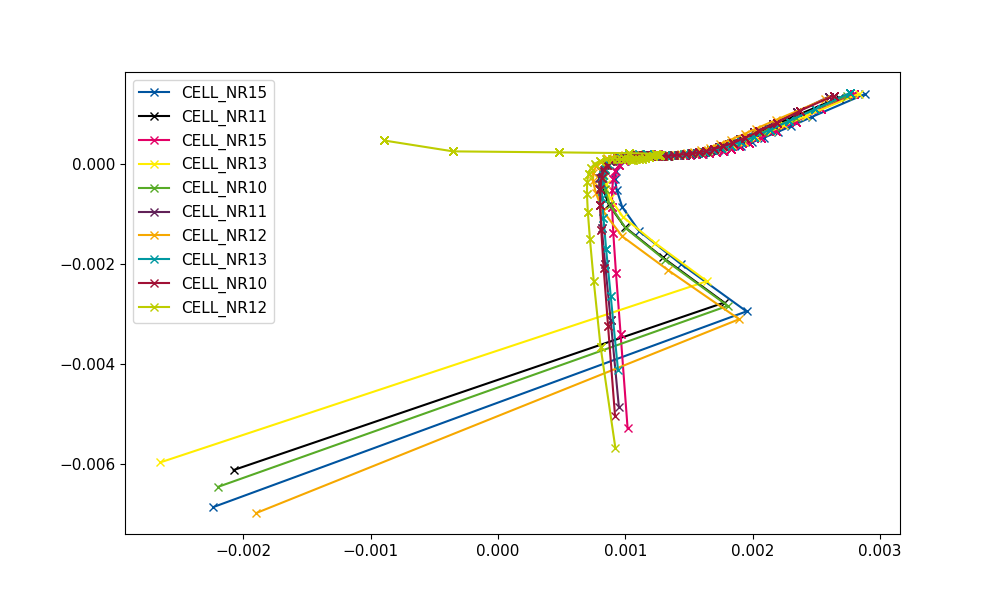

In [30]:
# path = r"Z:\Forschung\bgA\J7045_Futavis_Modultests\Daten\5_EIS\MultivsSweep"
path = r"Z:\Forschung\bgA\J7045_Futavis_Modultests\Daten\2_Data_Futavis\Zellen\Zyklische Alterung\Abschlussprüfung\Extremes Profil\EX EIS END\25C\10"
List_Cell=[]
cellpath=[]
Df_List=[]
List_Cell = glob.glob1(path, '*.csv')
#Testset=input()
Testset = List_Cell[0].split("=")[1].split("_")[-1]
fig, ax = plt.subplots(clear=True, figsize=(10, 6))

for cell in List_Cell:
    fullpath = path + '/' + cell
    cellpath.append(fullpath)
    print(cell)
    df_read = pd.read_csv(fullpath,sep = ',')
    #print(df_read.columns.tolist())
    
    df_read = pd.read_csv(fullpath,sep = ',',
                        low_memory=False,
                        usecols = ['Freq','Re','Im',"activeChan","IscaleOut","Zustand"])
    df_read=df_read.iloc[1:]
    #df_read=df_read.astype(float)
    #df_read.activeChan=df_read.activeChan.astype(int)
    cols = df_read.columns
    df_read[cols[1:]] = df_read[cols[1:]].apply(pd.to_numeric, errors='coerce')
    df_read=df_read.sort_values(by="Freq")
    df_read=df_read.rename(columns={"Freq":"frequency","Re":"real impedance","Im":"imaginary impedance"})



    # Prepare for export
    number=globals()[Testset]
    for keys in number:
        if float(number[keys]["activeChan"]) == df_read.activeChan.iloc[0]:
            filename="CELL_"+keys+"_CH00_00001_"+ df_read.Zustand.iloc[0]
            filename=filename+".csv"
            ax.plot(df_read["real impedance"],-1*df_read["imaginary impedance"],marker="x",label="CELL_"+keys)

    df_read_export = df_read.drop(["activeChan","IscaleOut","Zustand"],axis=1)
    df_read_export.to_csv(path+ '/'+filename, index=False)

plt.legend()
plt.show

In [6]:
number

{'NR8': {'Number': 'NR8', 'activeChan': '1.0 '},
 'NR7': {'Number': 'NR7', 'activeChan': '2.0 '},
 'NR3': {'Number': 'NR3', 'activeChan': '3.0 '},
 'NR4': {'Number': 'NR4', 'activeChan': '4.0 '},
 'NR6': {'Number': 'NR6', 'activeChan': '5.0 '}}

KeyError: 'Name'

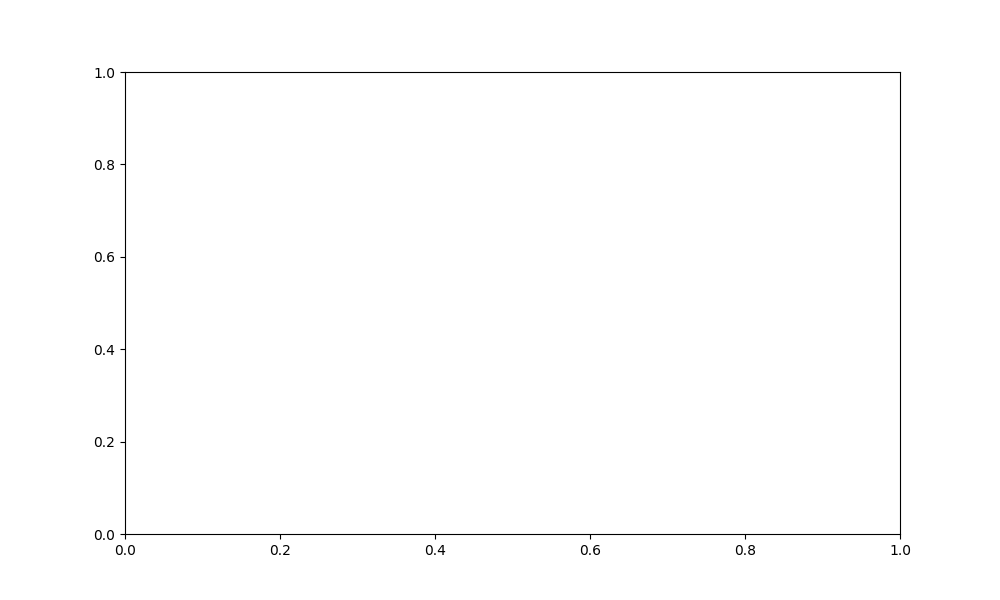

In [35]:
fig, ax = plt.subplots(clear=True, figsize=(10, 6))
for df_read in Df_List:
    df_read["imaginary impedance"]=-1*df_read["imaginary impedance"]
    ax.plot(df_read["real impedance"],df_read["imaginary impedance"],marker="x",label=df_read["Name"].iloc[1])
#df_read.plot()
plt.legend()
plt.show

NameError: name 'df_List' is not defined

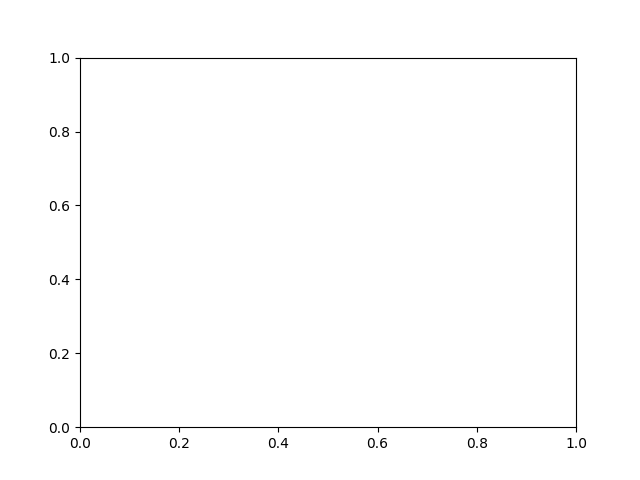

In [28]:
fig,ax = plt.subplots()

for df in df_List:
    ax.plot(df['Programmdauer'], df['Spannung'],label=df['Name'].iloc[1])

In [ ]:
df_List[0][df_List[0]['Spannung']<= 2.6]

# disensamble qOCV

In [60]:
files={}
dataset_number = []
df_List = []
cellpath = []
df_dict ={}
rootpath = r"Z:\Forschung\bgA\J7045_Futavis_Modultests\Daten\2_Data_Futavis\Zellen\Zyklische Alterung\compare_K25"
count = 0

List_Cell = glob.glob1(rootpath, '*.mat')
for cell in List_Cell:
    fullpath = rootpath + '/' + cell
    cellpath.append(fullpath)


for cell_file in cellpath:
    mat = loadmat(cell_file, struct_as_record=False, squeeze_me=True) 
    
    df_read1 = pd.DataFrame()
    spalten = mat['diga'].spalten_namen
    daten = mat['diga'].daten
    
    df_read1['Spannung']=mat['diga'].daten.Spannung
    df_read1['Spannung'].convert_dtypes().astype(float)

    df_read1['Strom']=mat['diga'].daten.Strom
    df_read1['Strom'].convert_dtypes().astype(float)

    df_read1['AhAkku']=mat['diga'].daten.AhAkku
    df_read1['AhAkku'].convert_dtypes().astype(float)

    df_read1['AhStep']=mat['diga'].daten.AhStep
    df_read1['AhStep'].convert_dtypes().astype(float)

    df_read1['AhLad']=mat['diga'].daten.AhLad
    df_read1['AhLad'].convert_dtypes().astype(float)

    df_read1['AhEla']=mat['diga'].daten.AhEla
    df_read1['AhEla'].convert_dtypes().astype(float)

    df_read1['Programmdauer']=mat['diga'].daten.Programmdauer
    df_read1['Programmdauer'].convert_dtypes().astype(float)/3600000
    df_read1['Programmdauer']=df_read1['Programmdauer']/3600000
    
    
    df_read1['Name'] = List_Cell[count]
    count = count+1
    
    df_read1['Zustand']=mat['diga'].daten.Zustand

    df_read1['Prozedur']=mat['diga'].daten.Prozedur
    df_read1['Schritt']=mat['diga'].daten.Schritt
    df_read1['Schritt'].convert_dtypes().astype(int)

    df_List.append(df_read1)
    
    # filter qOCV
    #df_read3 = df_read1.loc[(df_read1.Schritt>=65) ]
    
    # filter the first charge
    mask_NCHA = ((df_read1['Schritt'] != 7 ) & ( (df_read1['Prozedur']=="ddo_Futavis_Zelle_qOCV_derating") |(df_read1['Prozedur']=="ddo_Futavis_Zelle_qOCV"))) & ((df_read1['Schritt'] !=8)&( (df_read1['Prozedur']=="ddo_Futavis_Zelle_qOCV_derating") |(df_read1['Prozedur']=="ddo_Futavis_Zelle_qOCV")))
    df_read3= df_read1[mask_NCHA]
    # remove all pause
    mask_NPAU = df_read3['Zustand'] != "PAU"
    df_read3= df_read3[mask_NPAU]
    new_path = rootpath + '\\' + List_Cell[count-1].split(".")[0]+"_qOCV.csv"
    
    df_read3.to_csv(new_path,index=False)

# Compare qOCV

In [63]:
files={}
dataset_number = []
df_List = []
cellpath = []
df_dict ={}
rootpath = r"Z:\Forschung\bgA\J7045_Futavis_Modultests\Daten\2_Data_Futavis\Zellen\Zyklische Alterung\compare_EX"
count = 0

List_Cell = glob.glob1(rootpath, '*.csv')
for cell in List_Cell:
    fullpath = rootpath + '/' + cell
    cellpath.append(fullpath)


for cell_file in cellpath:
    df_read1 = pd.read_csv(cell_file,sep = ',')
    df_List.append(df_read1)
    

df_List_shifted_Ah = []
    
for cell_df in df_List:
    reference = cell_df[(cell_df['Spannung']<= 2.61)].AhAkku.index[0]
    reference_num = cell_df.loc[reference].AhAkku
    cell_df.AhAkku = cell_df.AhAkku - reference_num
    df_List_shifted_Ah.append(cell_df)

In [64]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter


def smooth_and_calculate_dvdq(df, window=5000, poly_order=4):
    # 1. First smooth the voltage data
    df_smooth = df.copy()
    df_smooth['voltage_smooth'] = savgol_filter(df['Spannung'], window, poly_order)
    
    # 2. Calculate dV/dQ using the smoothed voltage
    voltage_diff = np.diff(df_smooth['voltage_smooth'])
    amphours_diff = np.diff(df_smooth['AhStep'])
    dv_dq = voltage_diff / amphours_diff
    df_smooth['dV_dQ'] = np.concatenate([dv_dq, [dv_dq[-1]]])
    
    # 3. Apply Savitzky-Golay filter to the derivative
    df_smooth['dV_dQ'] = savgol_filter(df_smooth['dV_dQ'], window, poly_order)
    df_smooth["dV_dQ"].iloc[-3] = 0
    return df_smooth


def calc_dva_by_interpolation(df,capacity,voltage):
    # DVA-Calculation using difference quotient
    # Length of Ah-step for computation of differences quotient (standard value - literature: 0.1-0.2% of total capacity)
    Ah_step_length = 0.002  # Length of Ah-step
    delta_Ah = abs(max(capacity) * Ah_step_length)  # delta_Ah for calculation of difference quotient
    # Calculation of difference quotient of filtered OCV
    int_funct_DVA = interp1d(capacity, voltage, fill_value="extrapolate")
    dva = (int_funct_DVA(capacity + delta_Ah) - int_funct_DVA(capacity - delta_Ah)) / (2*delta_Ah)
    return dva


C:\Users\zho\AppData\Local\Temp\ipykernel_18420\3974280169.py:14: RuntimeWarning: divide by zero encountered in divide
  dv_dq = voltage_diff / amphours_diff
C:\Users\zho\AppData\Local\Temp\ipykernel_18420\3974280169.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retur

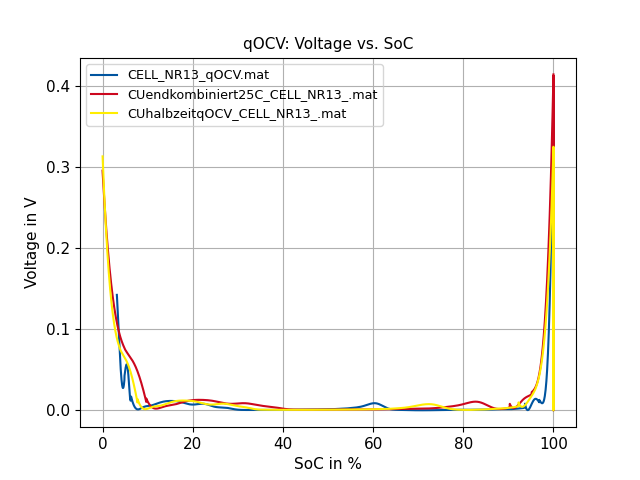

In [67]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots()

for df in df_List_shifted_Ah:
    if "NR13" in df.Name.iloc[0] :
        df = df[df.Zustand == "CHA"].copy()
        df = smooth_and_calculate_dvdq(df)

        if "CUend" in df.Name.iloc[0]:
            color=rwth_colors.colors[('red', 100)]
        elif "CUhalbzeit" in df.Name.iloc[0]:
            color=rwth_colors.colors[('yellow', 100)]
        else:
            color=rwth_colors.colors[('blue', 100)]

        #ax.plot((df['AhAkku']/df['AhAkku'].max()*100), (df['voltage_smooth']), label=df['Name'].iloc[1],c=color)

        ax.plot((df['AhAkku']/df['AhAkku'].max()*100), df["dV_dQ"], label=df['Name'].iloc[1],c=color)

plt.title('qOCV: Voltage vs. SoC')
ax.set_xlabel("SoC in %")
ax.set_ylabel("Voltage in V")
ax.grid()
ax.legend(loc='lower right',bbox_to_anchor=(1,0))

legend = plt.legend(fontsize='small')

plt.show()

#fig.savefig(rootpath+'checkup-verlauf.svg', format = 'svg', dpi=300,bbox_inches = "tight")

<IPython.core.display.Javascript object>

C:\Users\zho\AppData\Local\Temp\ipykernel_11680\2081178404.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


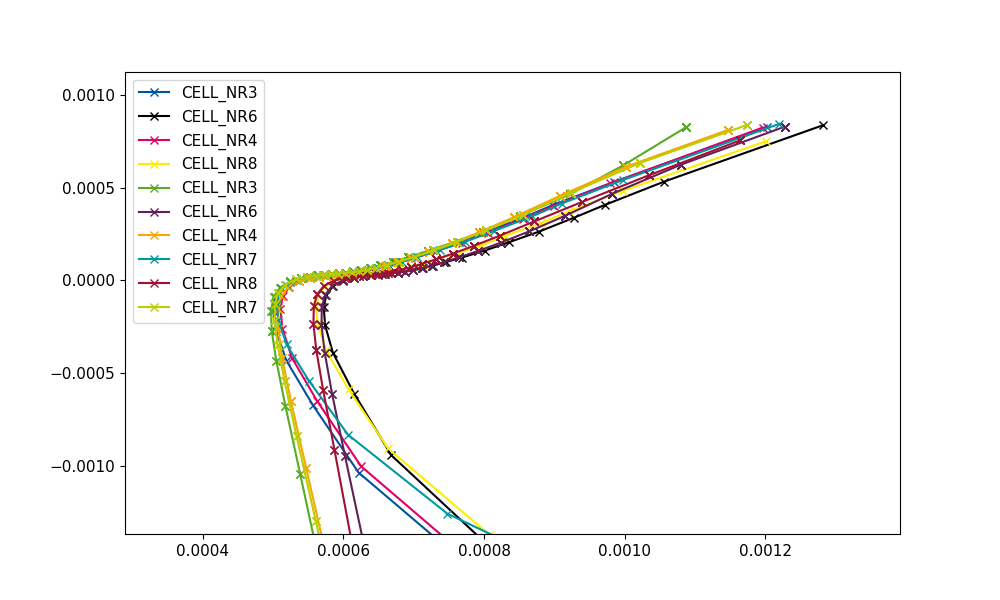

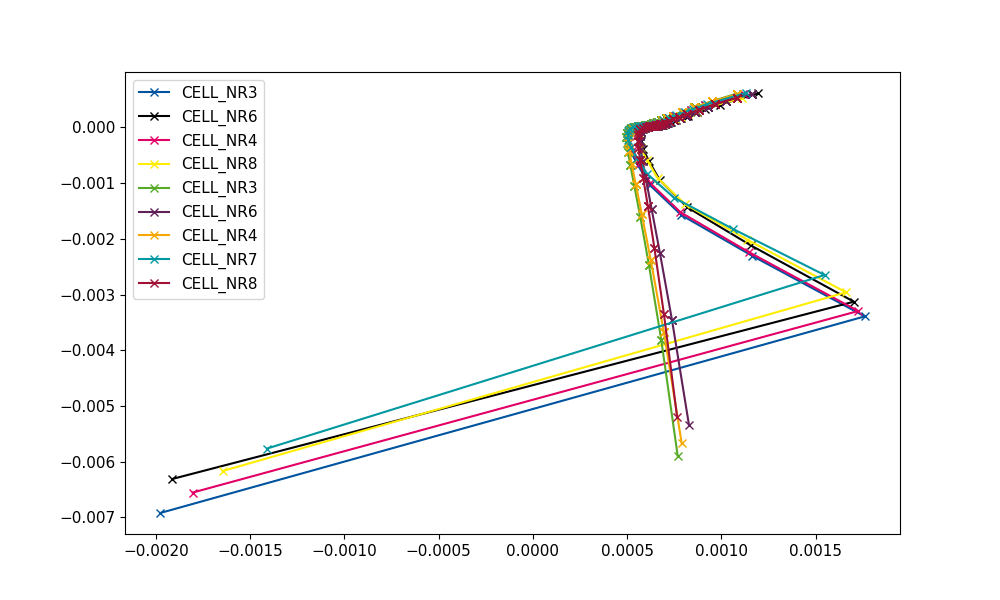

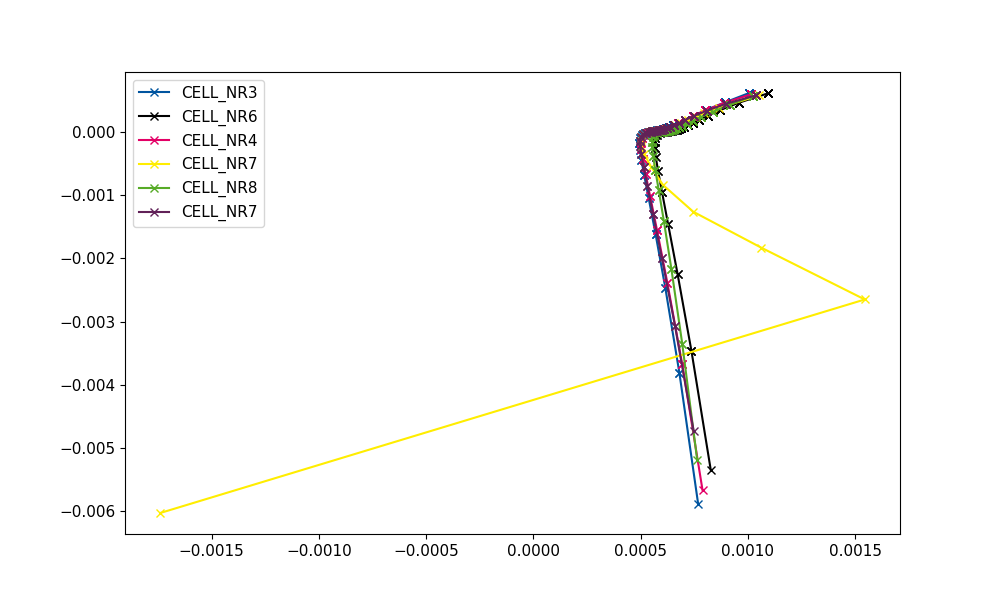

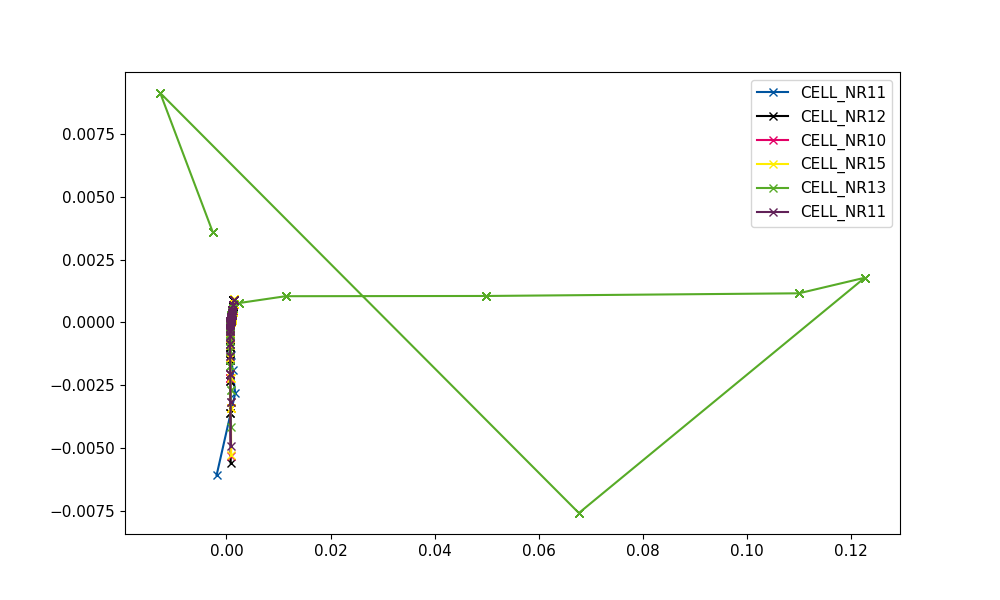

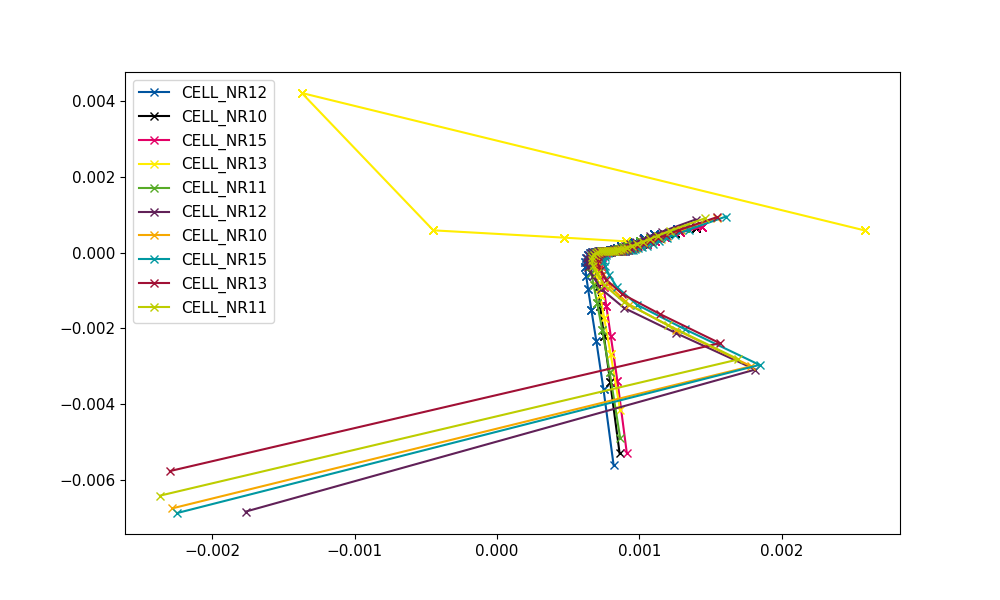

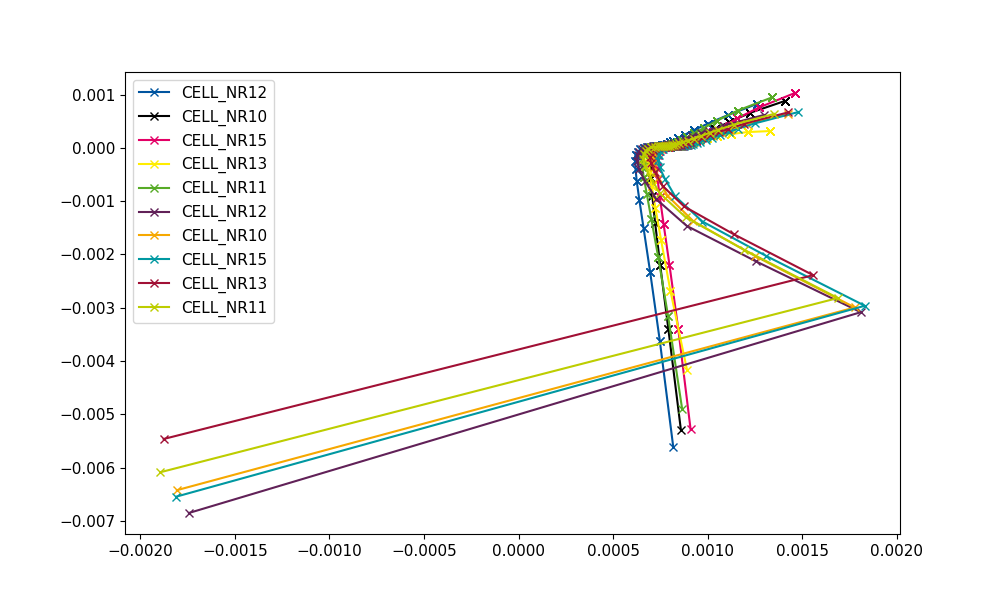

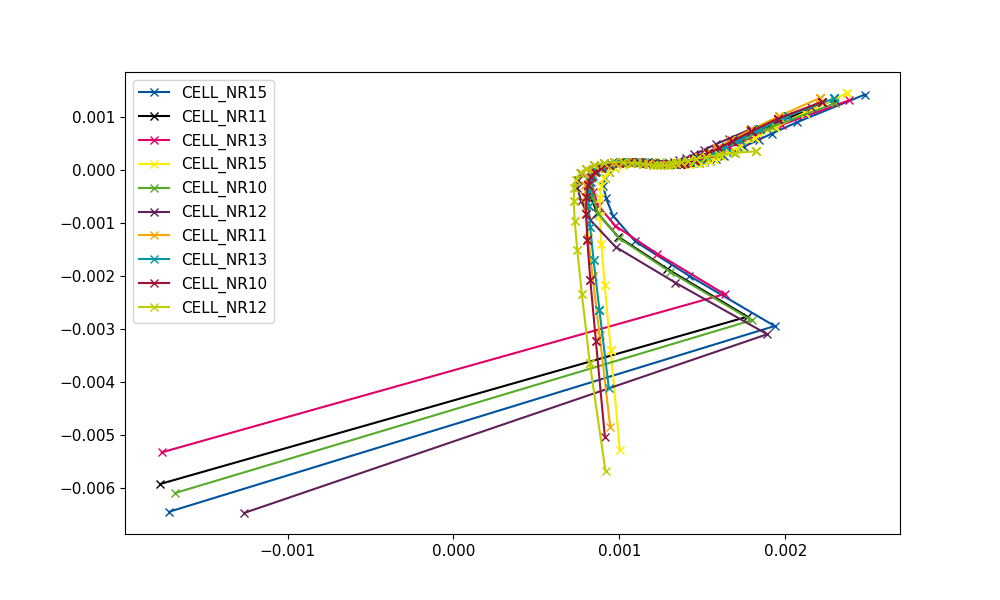

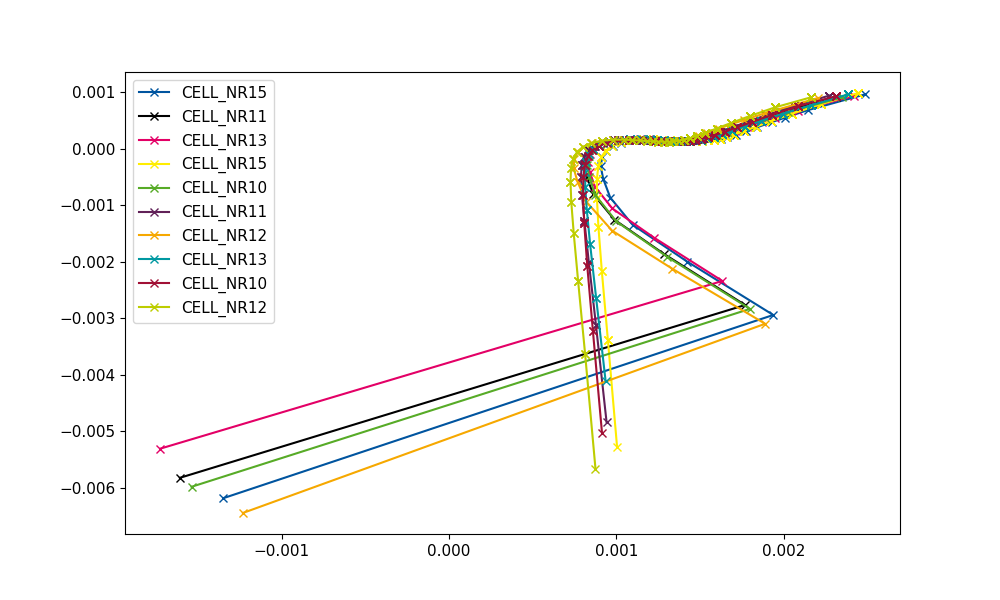

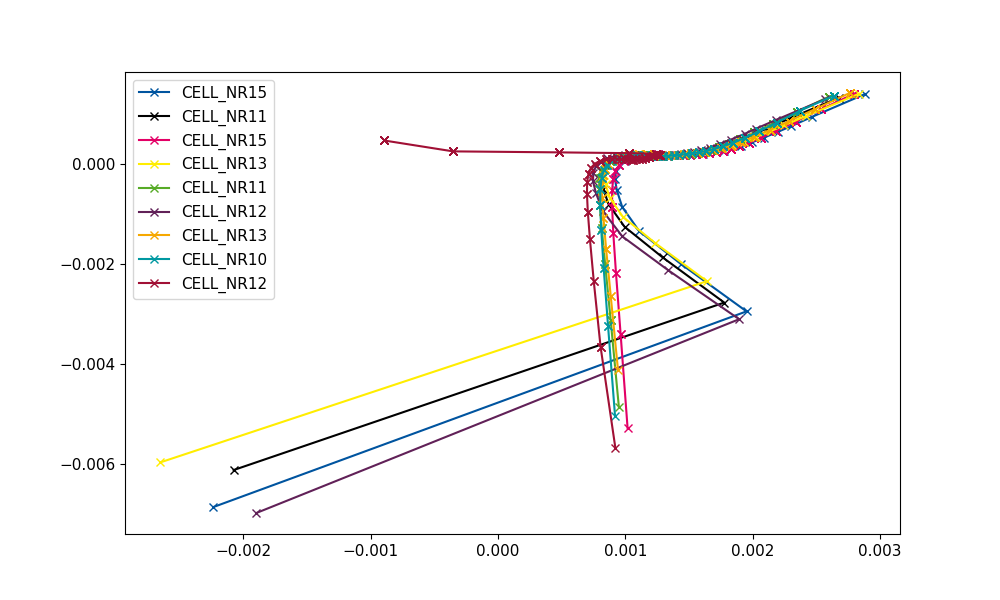

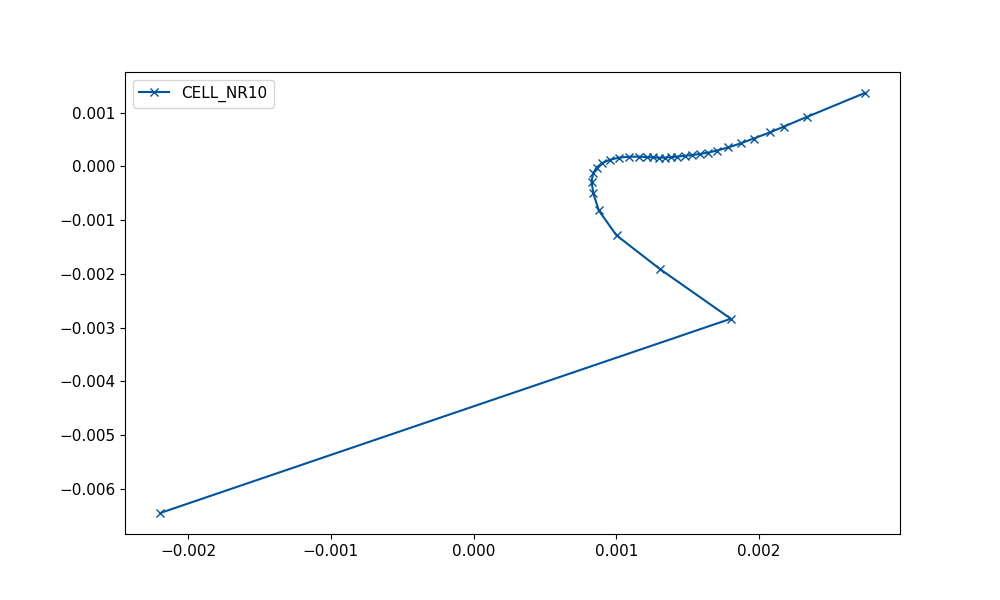

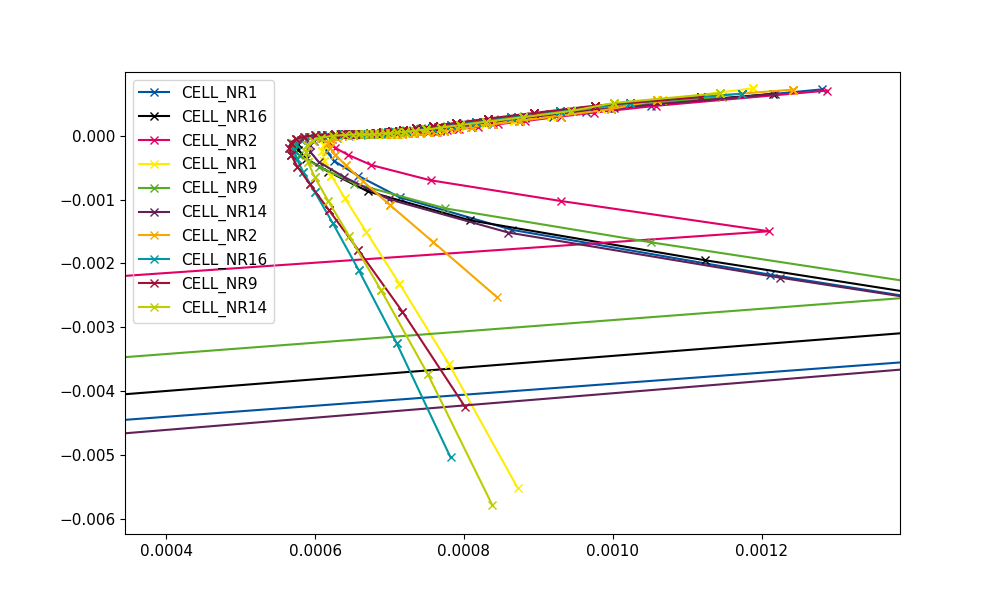

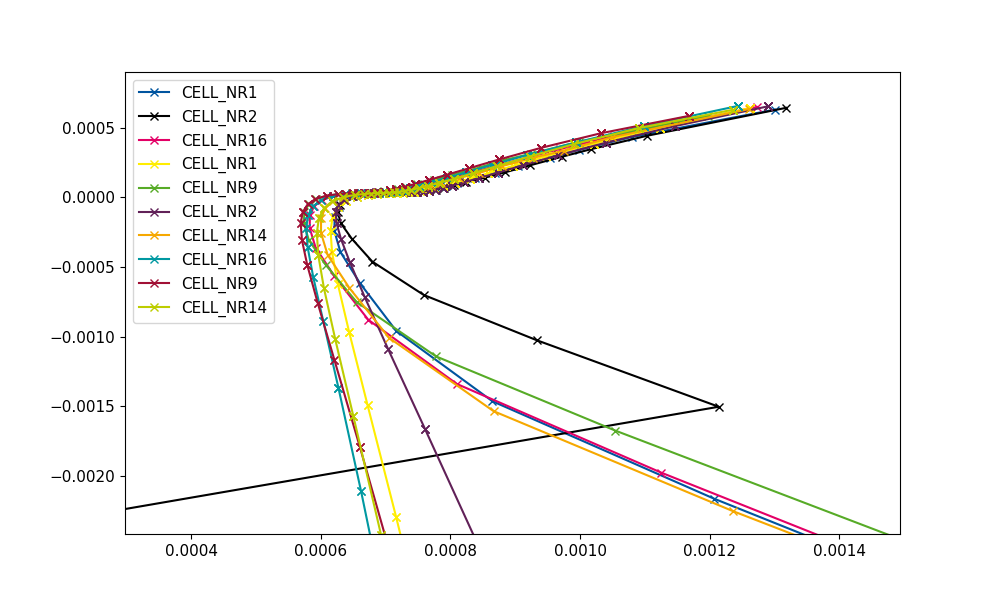

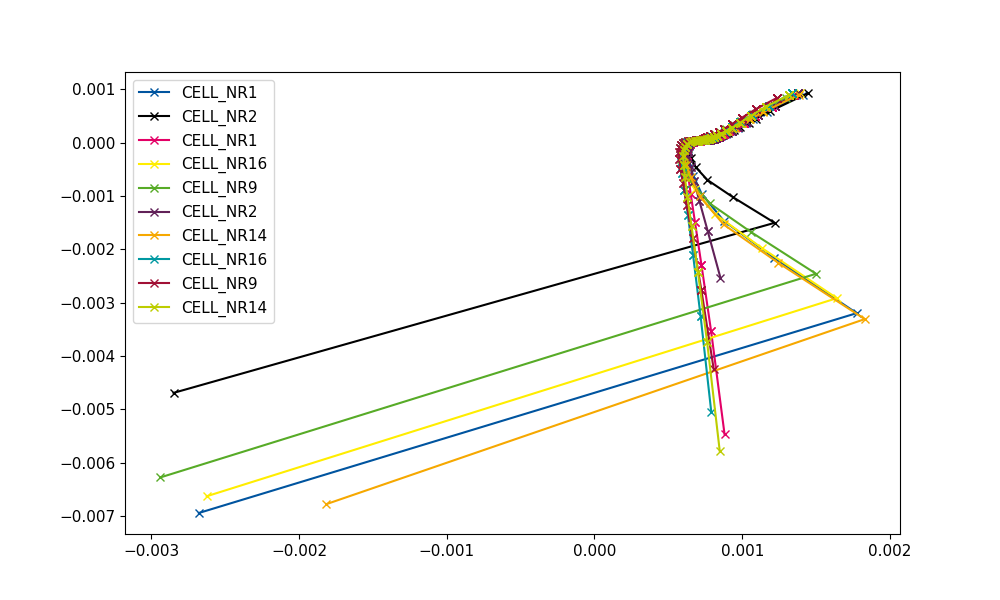

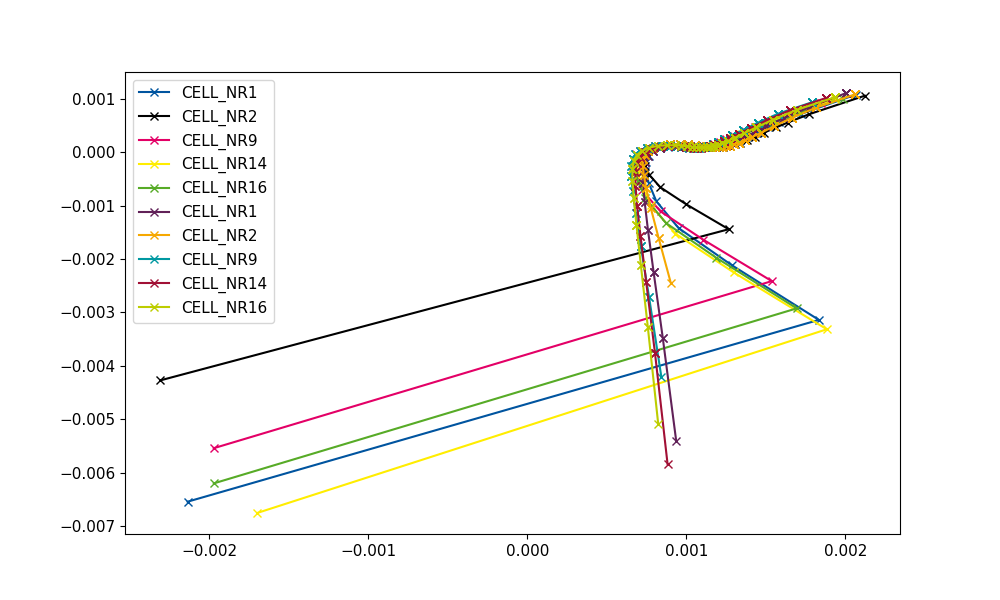

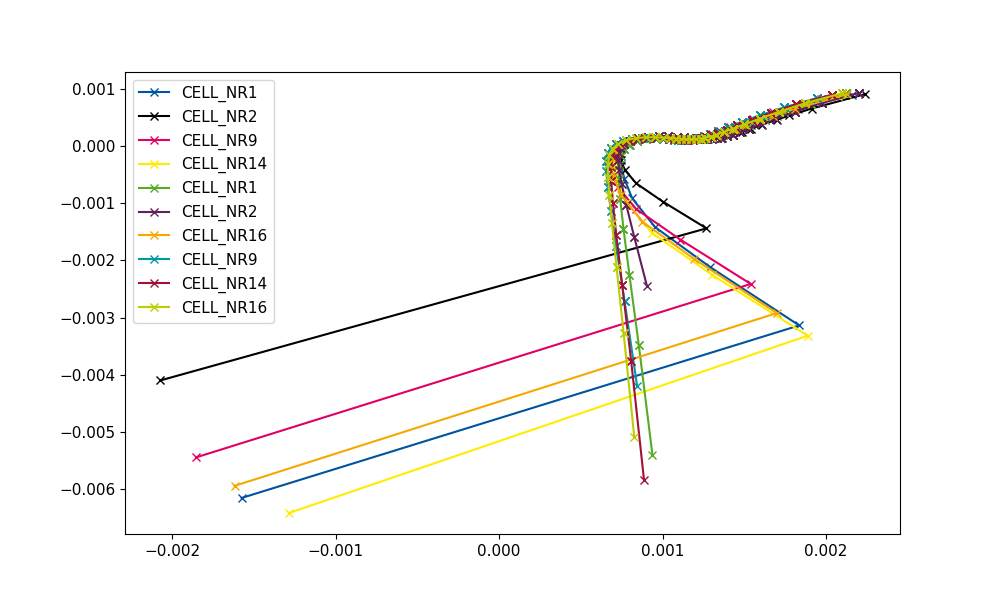

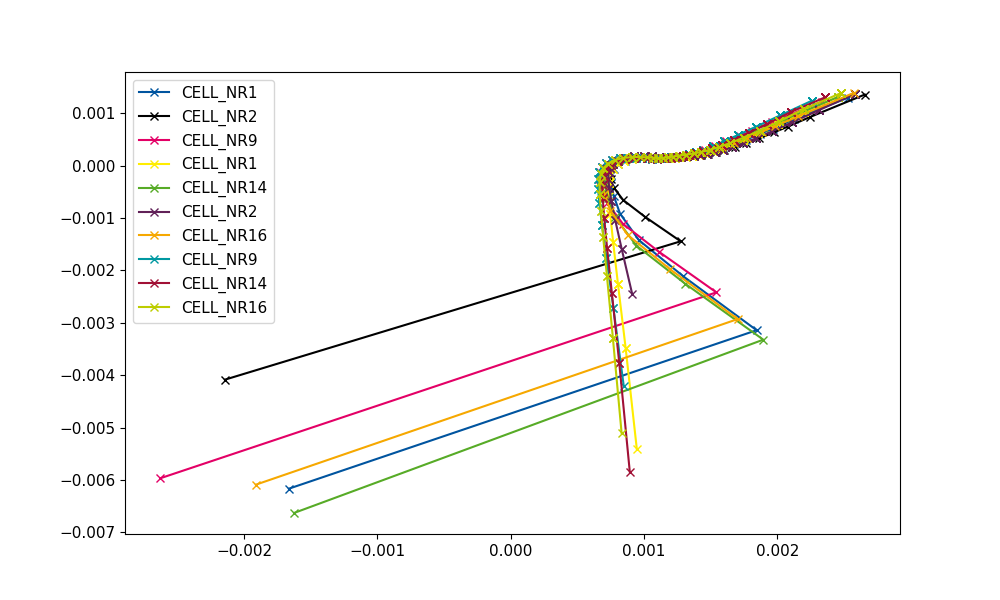

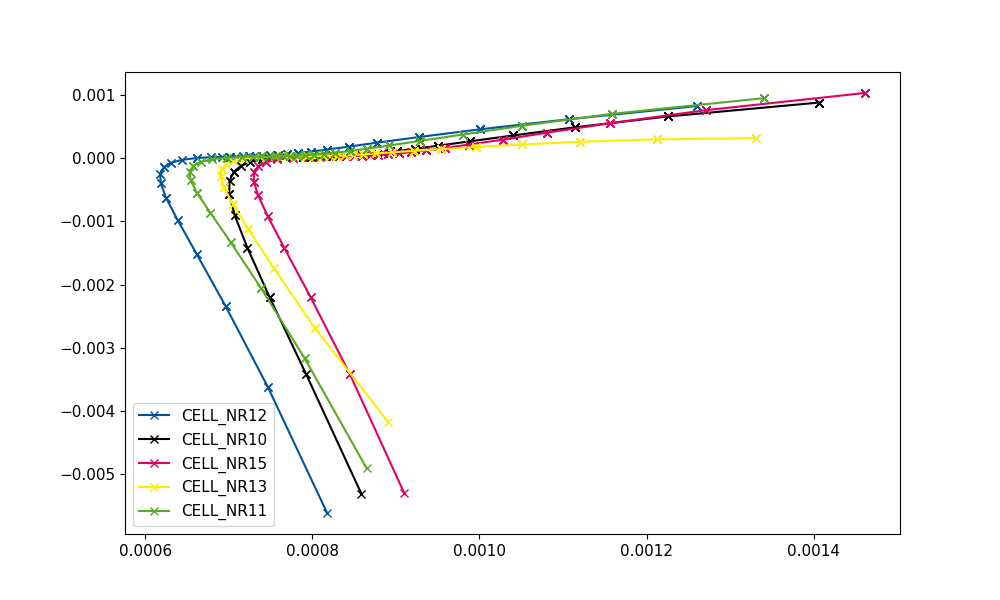

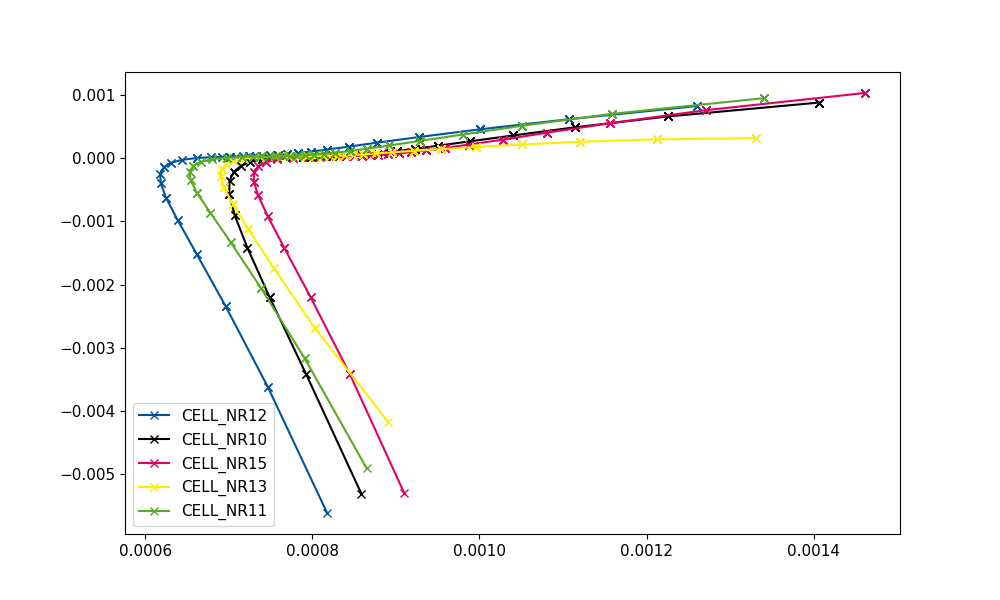

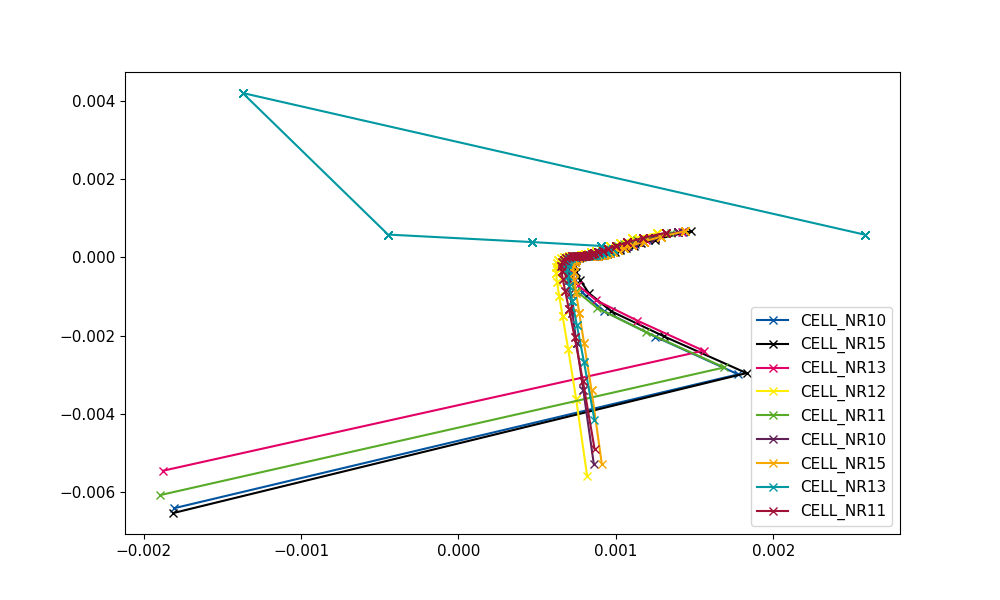

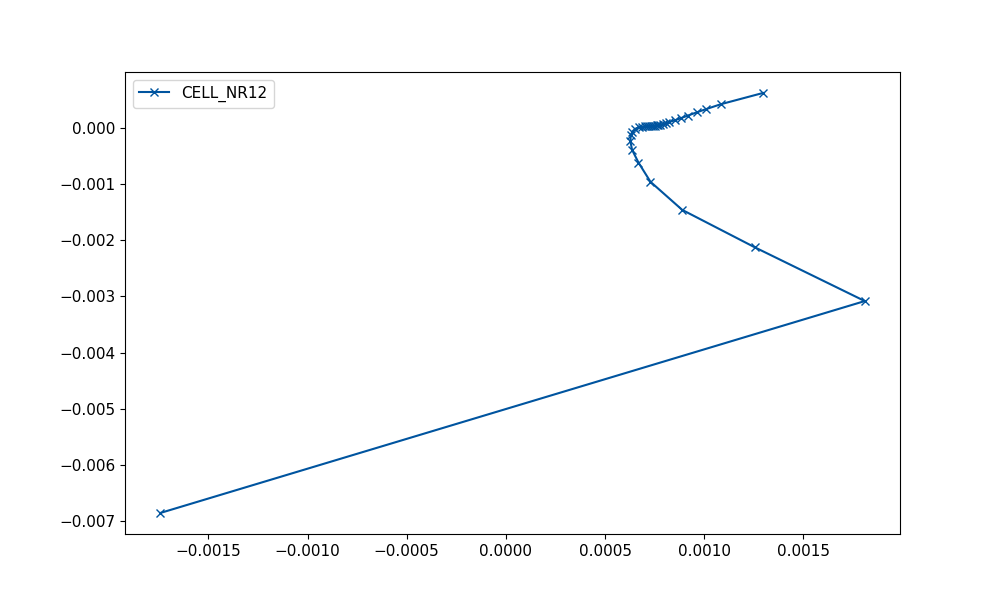

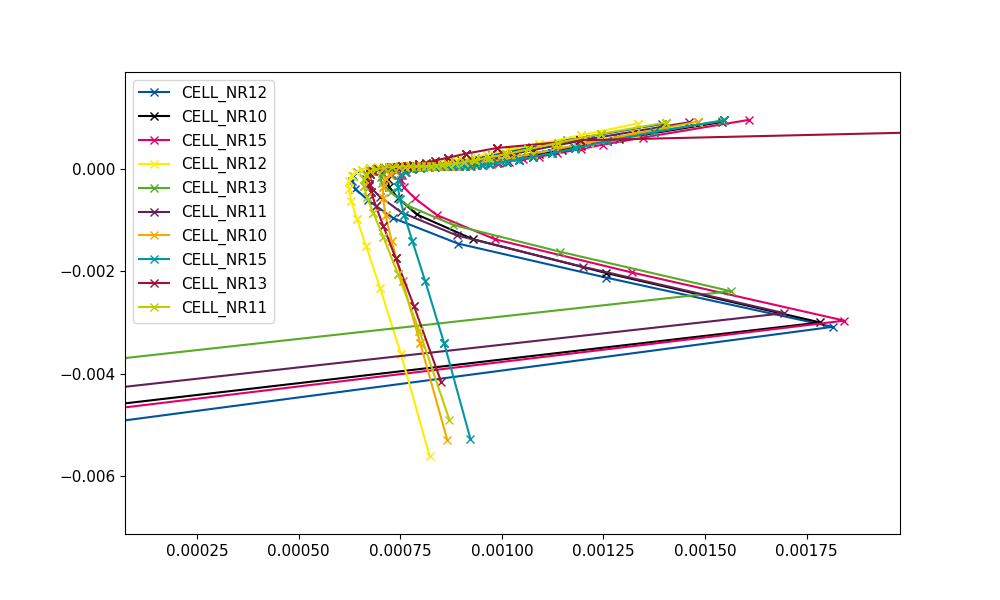

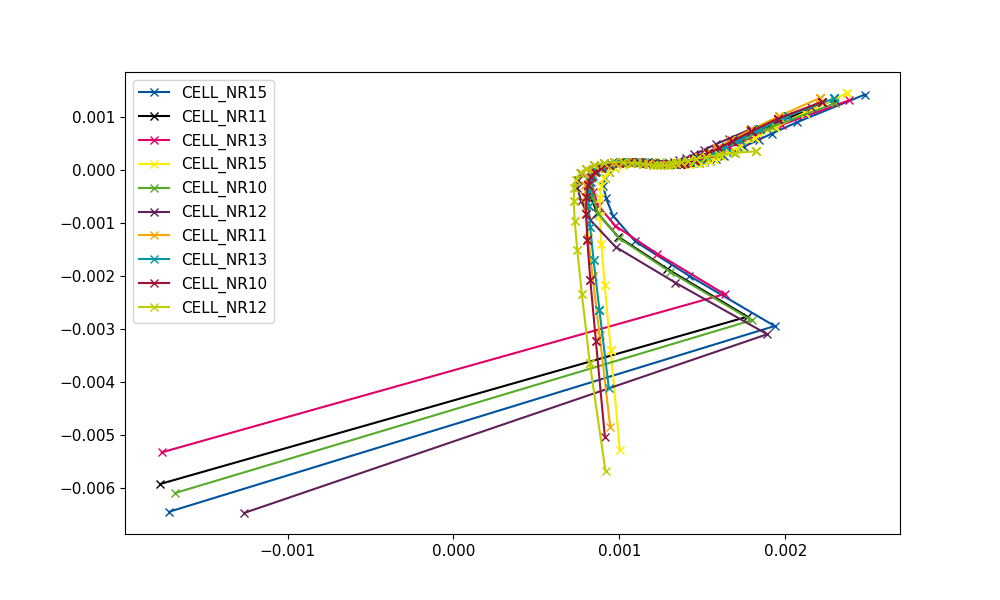

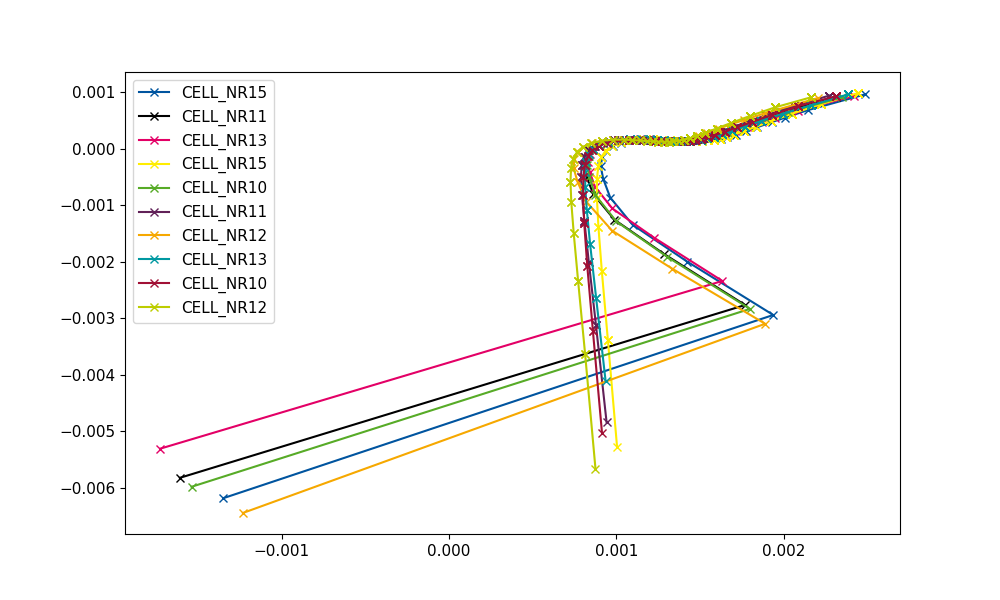

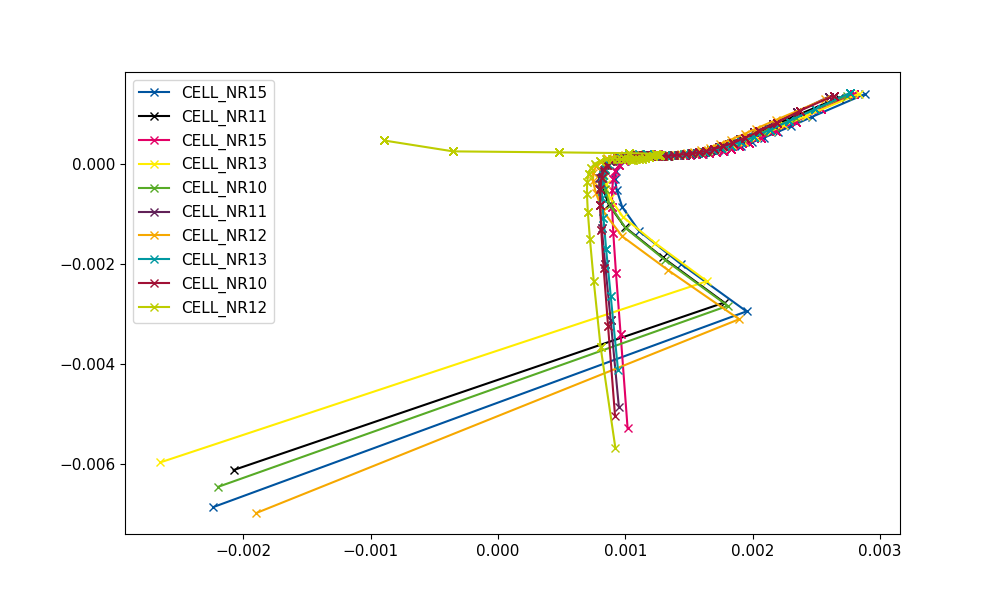

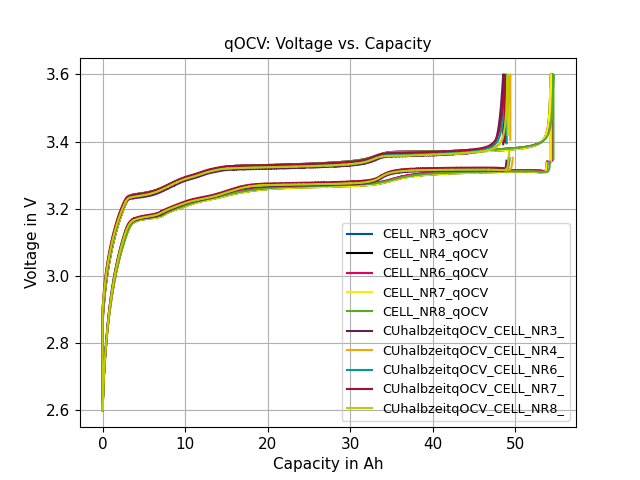

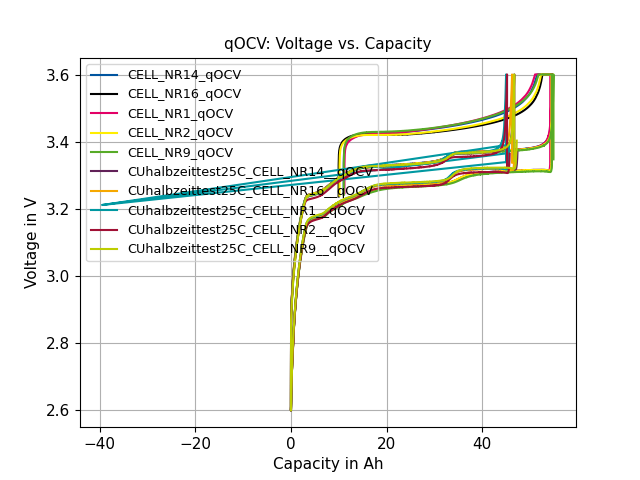

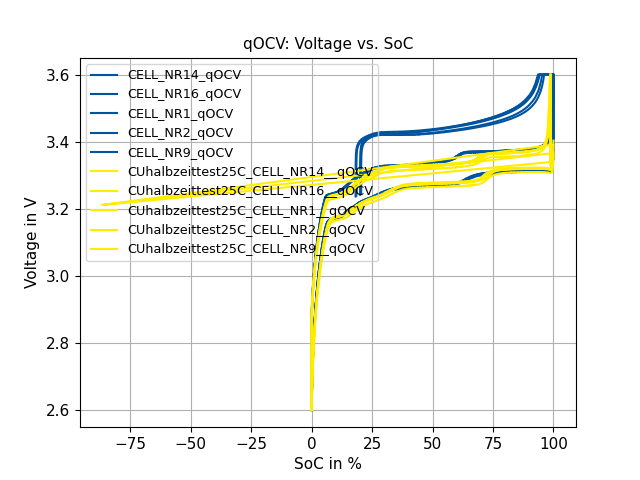

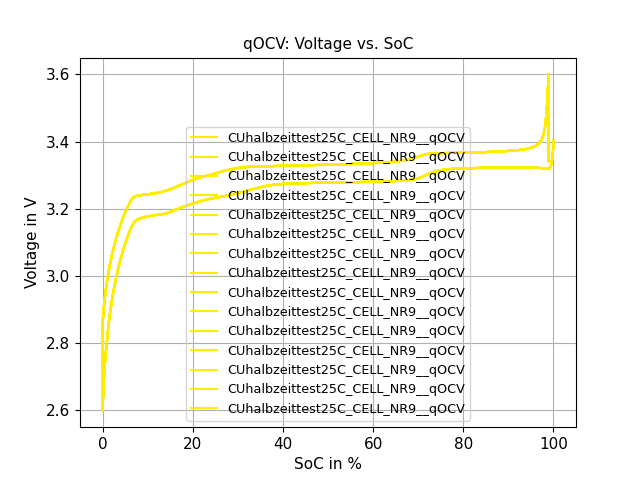

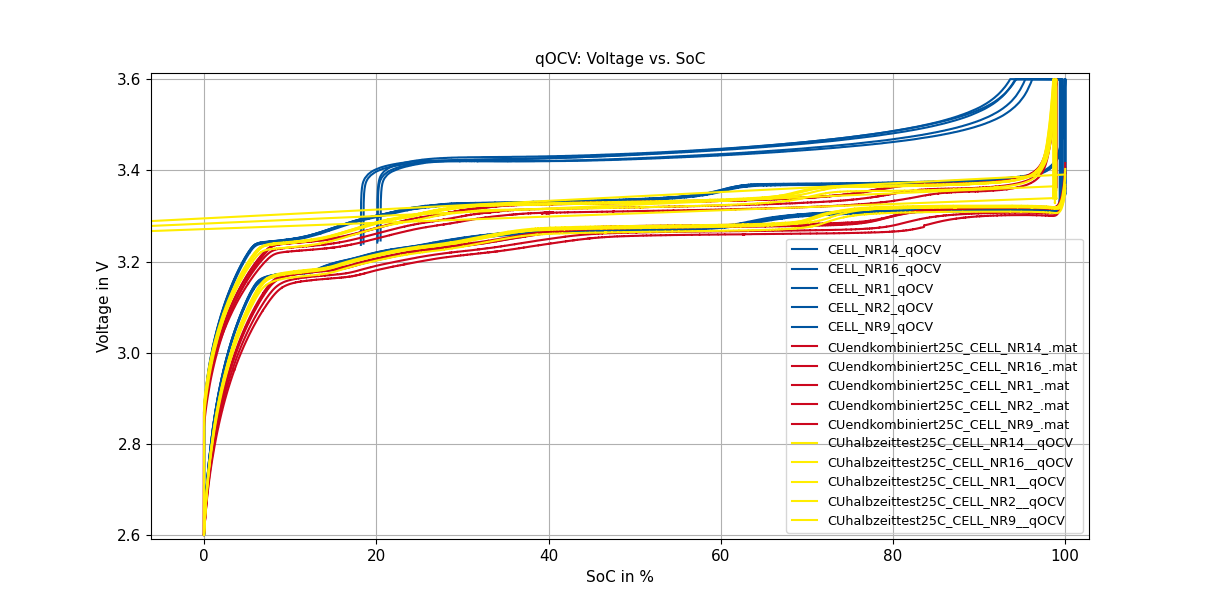

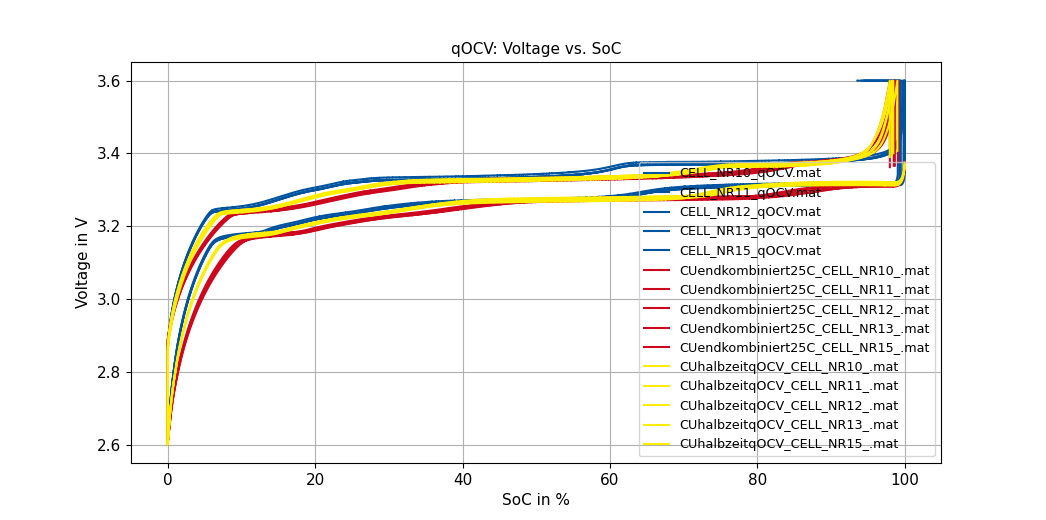

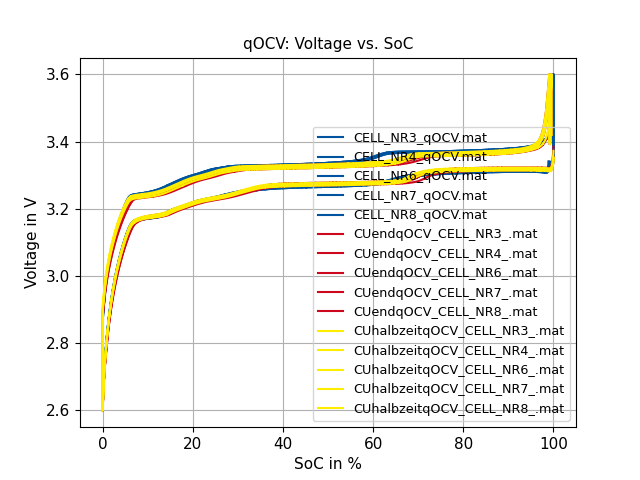

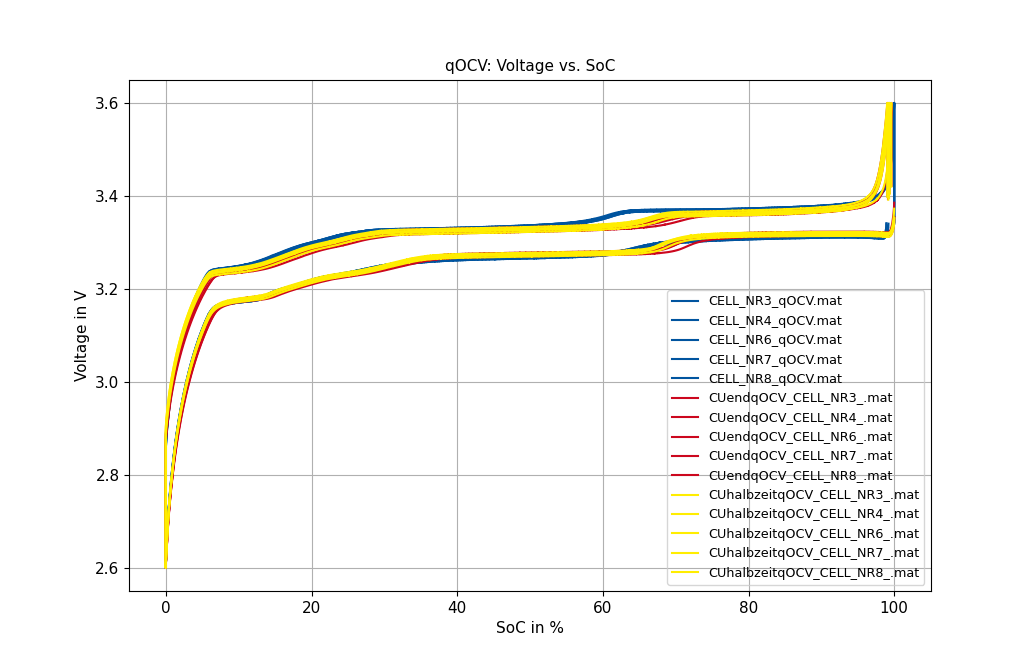

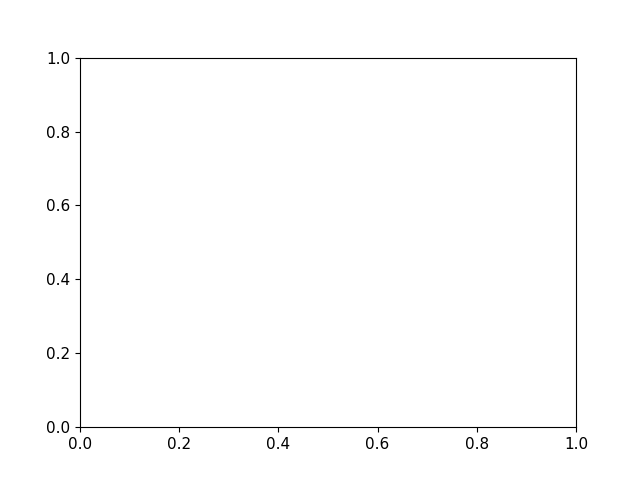

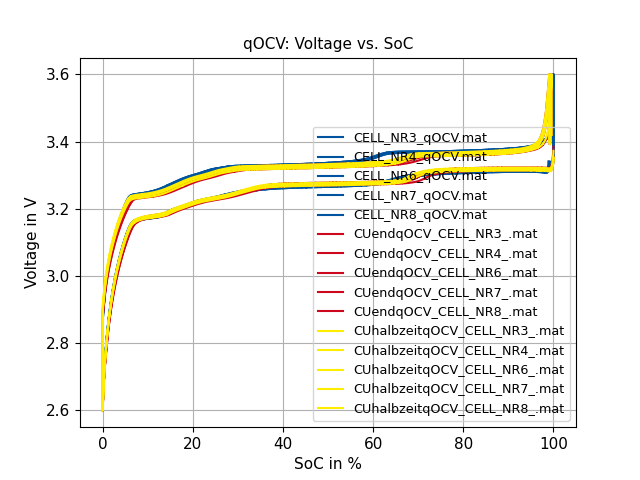

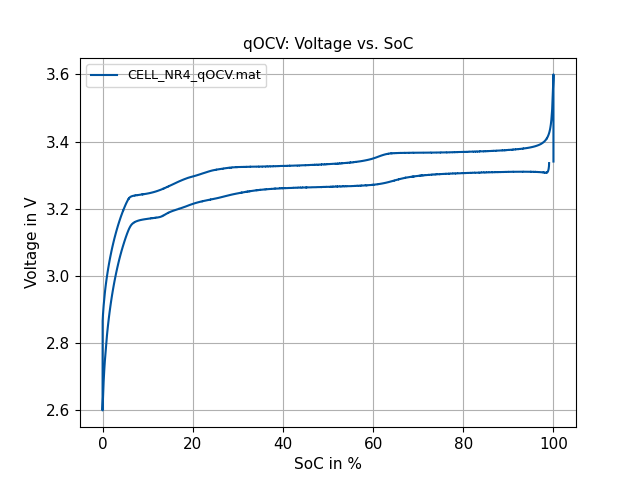

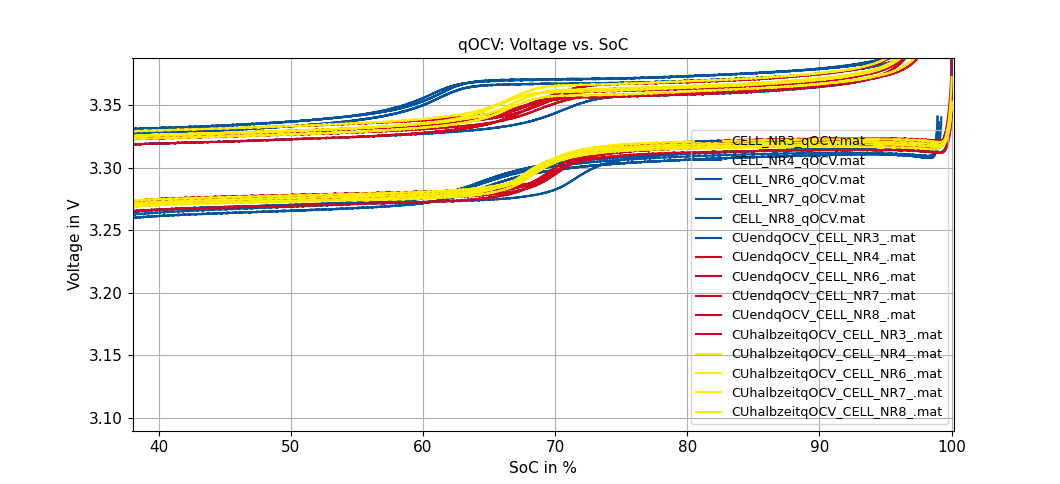

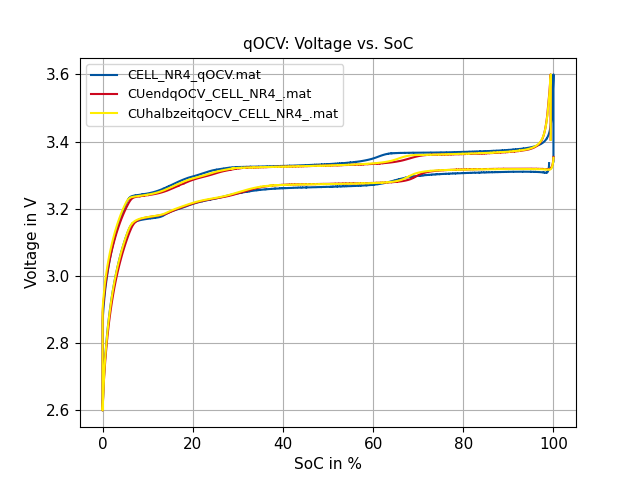

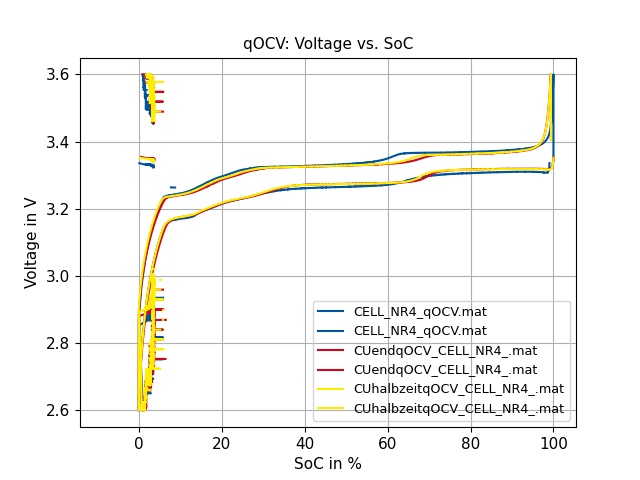

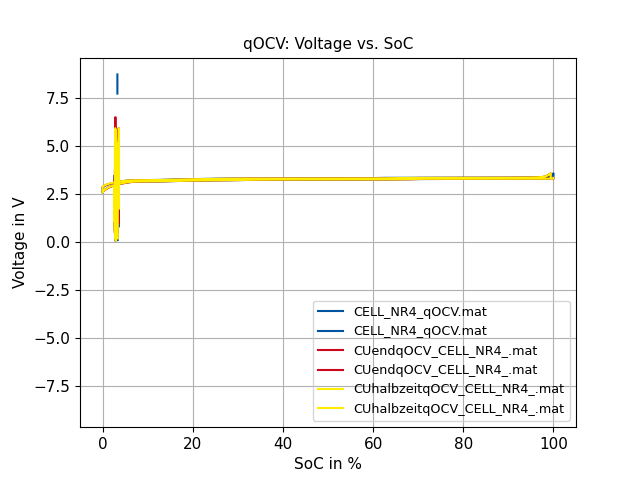

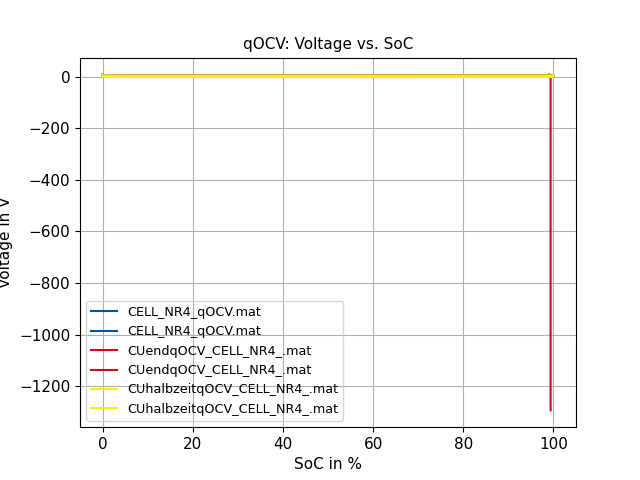

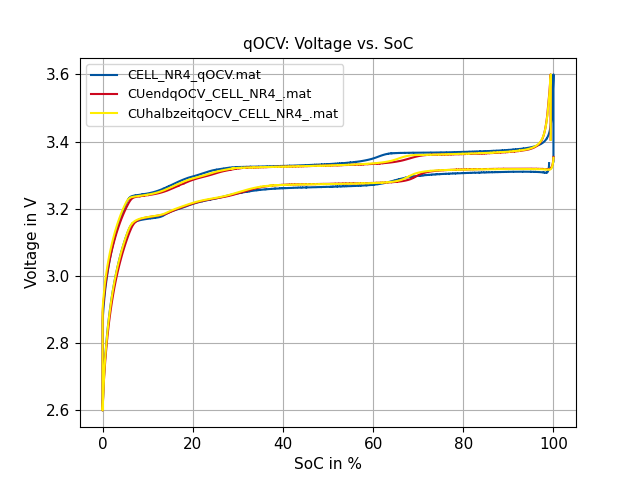

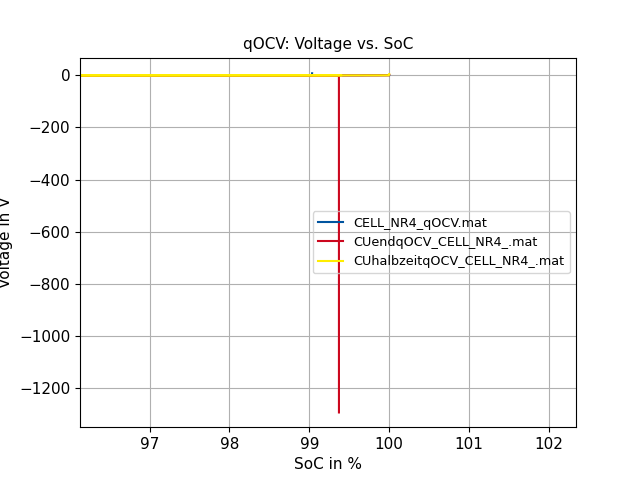

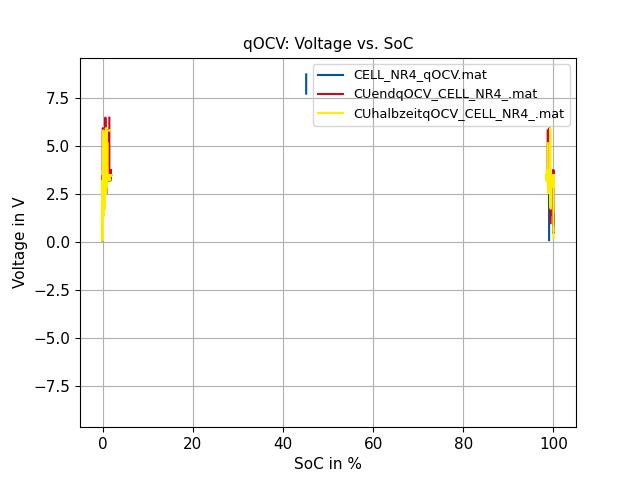

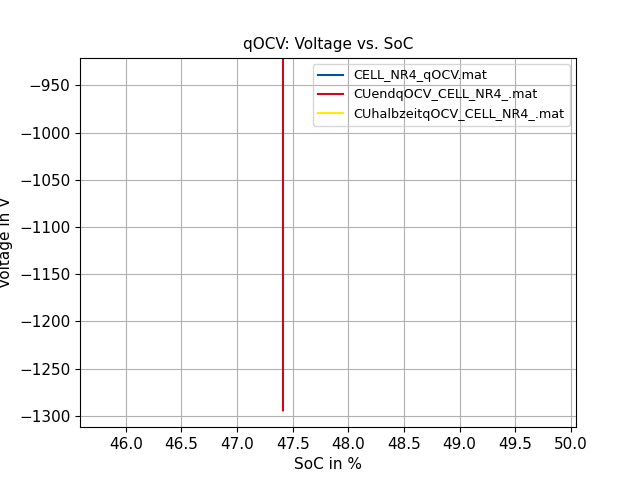

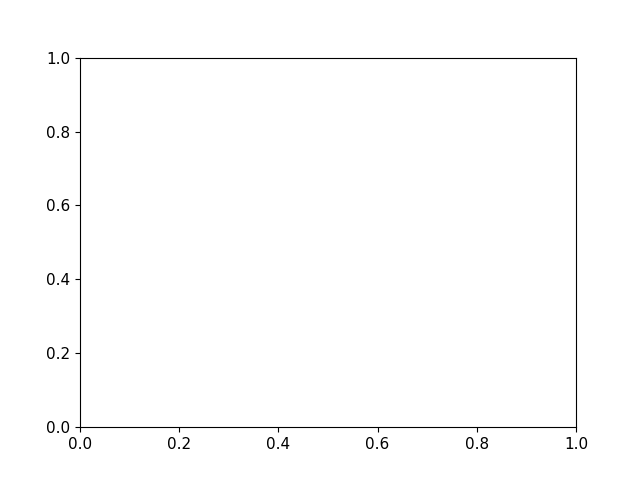

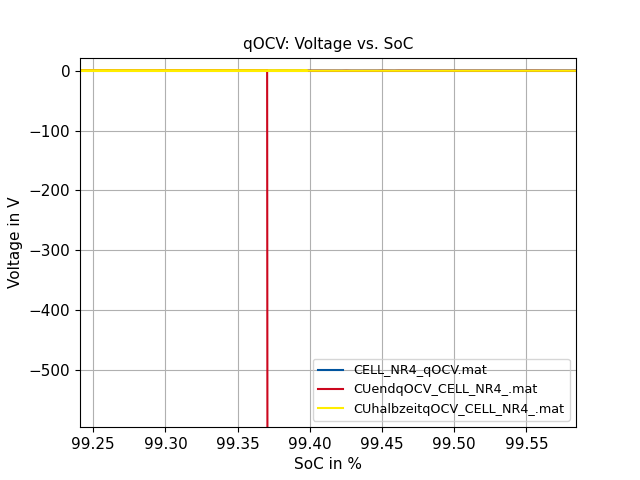

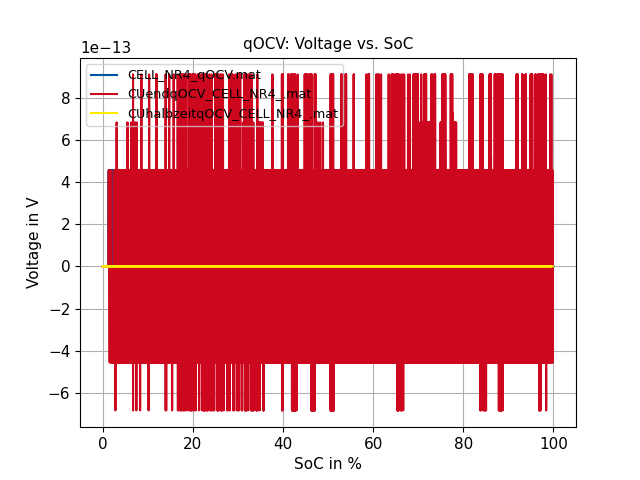

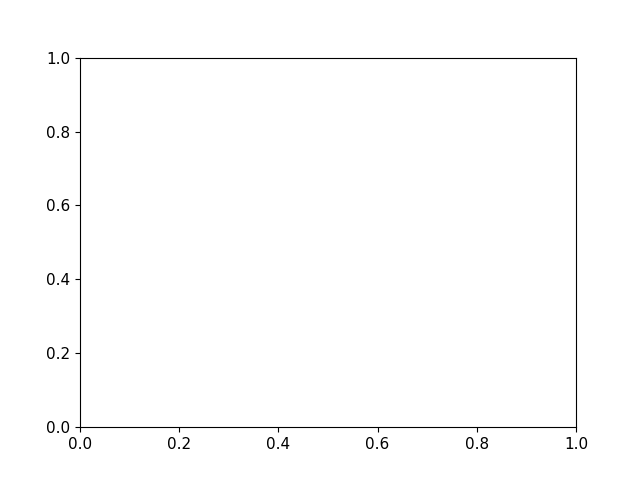

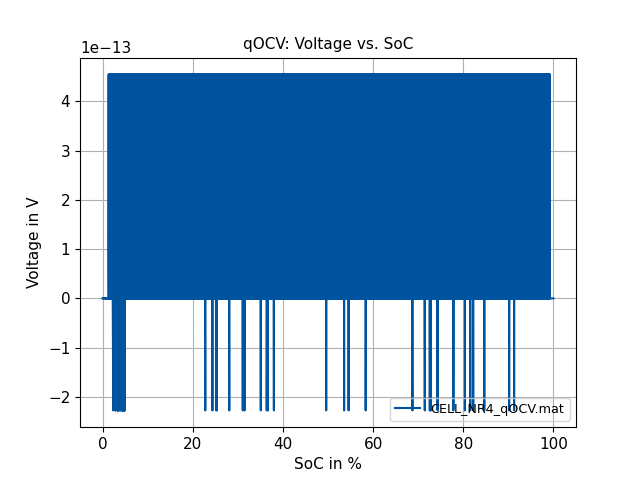

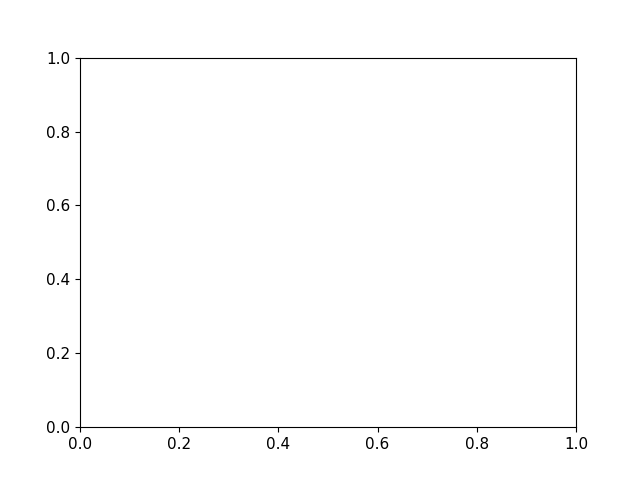

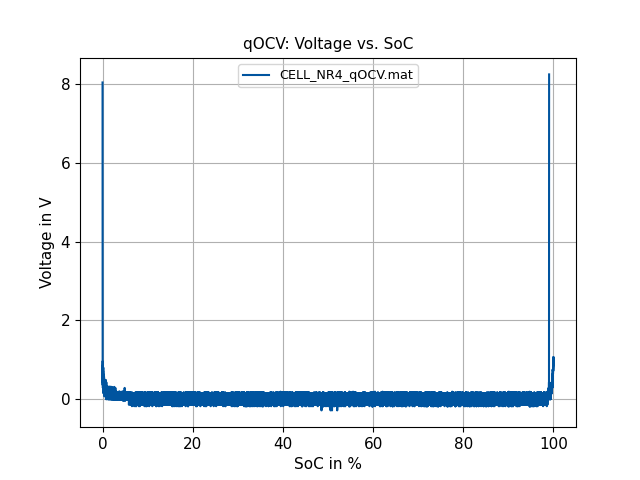

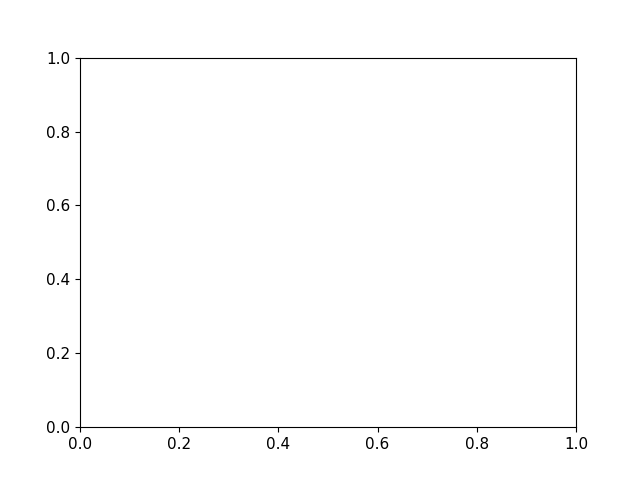

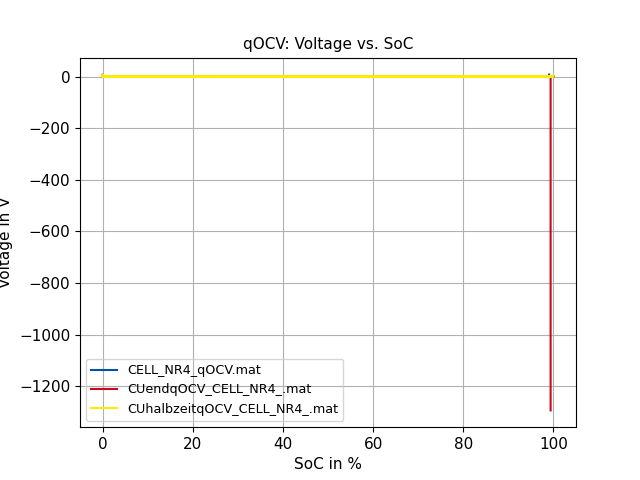

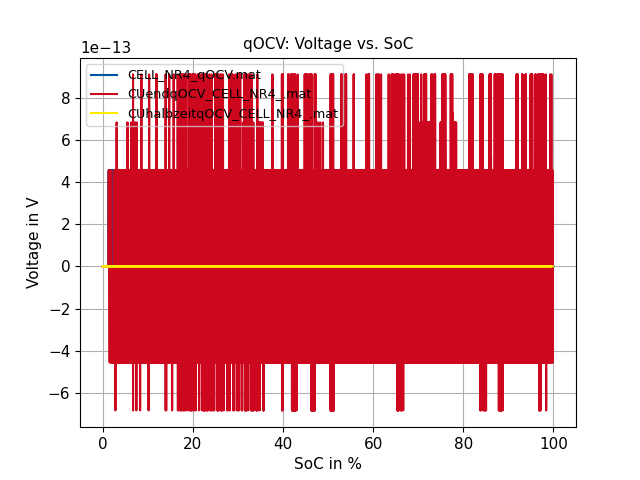

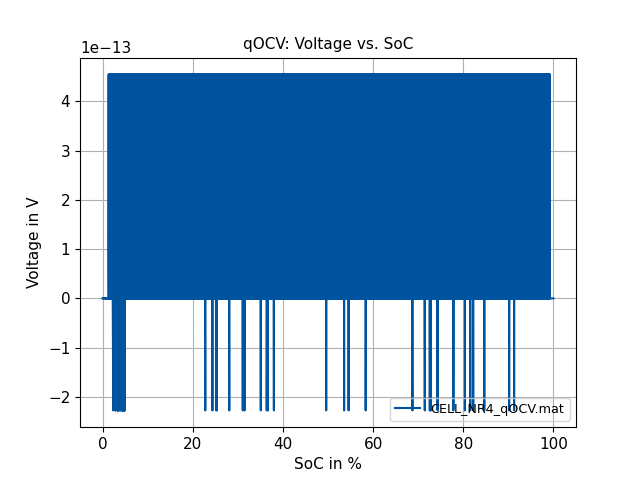

KeyboardInterrupt: 

In [154]:
path=r"Z:\Forschung\bgA\J7045_Futavis_Modultests\Daten\2_Data_Futavis\Zellen\Zyklische Alterung\Initial\Zellen_EIS\Zellen_EIS_45C\compare"
files={}
dataset_number = []
df_List = []
cellpath = []
df_dict ={}
rootpath = path

List_Cell = glob.glob1(rootpath, '*.csv')
for cell in List_Cell:
    fullpath = rootpath + '/' + cell
    cellpath.append(fullpath)


for cell_file in cellpath:
    df_read = pd.read_csv(cell_file,sep = ';',
                          low_memory=False,
                          usecols = ['frequency','real impedance','imaginary impedance'])
    df_read1 = df_read[1:]
    df_read1['frequency']=df_read1['frequency'][:-2].convert_dtypes().astype(float)
    df_read1['real impedance']=df_read1['real impedance'][:-2].convert_dtypes().astype(float)
    df_read1['imaginary impedance']=df_read1['imaginary impedance'][:-2].convert_dtypes().astype(float)
    df_read1['Name'] = cell_file.split('_')[-3]+'@'+cell_file.split('_')[-1][0:2]+'% SOC'

    df_List.append(df_read1)

# Plot
%matplotlib notebook
fig,ax = plt.subplots()

for df in df_List:
    ax.plot(df['real impedance']*1000, -df['imaginary impedance']*1000,label=df['Name'].iloc[1])

ax.set_xlabel("Real Impedance in mOhm")
ax.set_ylabel("Imaginary Impedance in mOhm")
ax.grid()
ax.legend()

plt.show()

In [ ]:
files={}
dataset_number = []
df_List = []
cellpath = []
df_dict ={}

file = r"C:\30_Projects\Futavis\Testdaten\Module\Phase 5\CELL_NR1_Phase5_2.mat"

mat = loadmat(file, struct_as_record=False, squeeze_me=True) 

df_read1 = pd.DataFrame()
df_read1['Spannung']=mat['diga'].daten.Spannung
df_read1['Spannung'].convert_dtypes().astype(float)

df_read1['Strom']=mat['diga'].daten.Strom
df_read1['Strom'].convert_dtypes().astype(float)

df_read1['AhAkku']=mat['diga'].daten.AhAkku
df_read1['AhAkku'].convert_dtypes().astype(float)

df_read1['Programmdauer']=mat['diga'].daten.Programmdauer
df_read1['Programmdauer'].convert_dtypes().astype(float)/3600000

df_read1['Programmdauer']=df_read1['Programmdauer']/3600000



In [ ]:
merge_df = pd.DataFrame(mat['diga'].daten)

In [ ]:
mat['diga'].daten

In [ ]:
df_List

In [ ]:
mat['diga'].daten.Spannung.dtype

In [ ]:
files={}
dataset_number = []
df_List = []
cellpath = []
df_dict ={}
rootpath = r'C:\30_Projects\Futavis\Testdaten\Zellen\Zyklische Alterung\K45\Alterungszyklus 4'

List_Cell = glob.glob1(rootpath, '*.csv')
for cell in List_Cell:
    fullpath = rootpath + '/' + cell
    cellpath.append(fullpath)


for cell_file in cellpath:
    df_read = pd.read_csv(cell_file,sep = ',',
                          low_memory=False,
                          usecols = ['Spannung','AhAkku','Programmdauer','Temperatur'])
    df_read1 = df_read[1:]
    df_read1['Spannung']=df_read1['Spannung'].convert_dtypes().astype(float)
    df_read1['AhAkku']=df_read1['AhAkku'].convert_dtypes().astype(float)
    df_read1['Temperatur']=df_read1['Temperatur'].convert_dtypes().astype(float).round(2)
    df_read1['Programmdauer']=df_read1['Programmdauer']/3600000
    #df_read1 = df_read1[df_read1['Spannung']<=5]
    #df_read1.loc[df_read1['AhAkku'] > 5.0, 'AhAkku'] = 0
    df_read1['Name'] = cell_file.split('_')[2]

    df_List.append(df_read1.round(4))
        
%matplotlib notebook
#plt.rcParams['axes.grid']=True
fig,ax = plt.subplots()

df_List_shifted = []

reference = df_List[0][(df_List[0]['Spannung']>= 3.5999)].Programmdauer.index[0]
df_List_shifted.append(df_List[0])

for cell_df in df_List[1:]:
    offset = reference - cell_df[cell_df['Spannung']>=  3.5999].Programmdauer.index[0]
    mask = ~(cell_df.columns.isin(['Programmdauer','Name']))
    cols_to_shift = cell_df.columns[mask]
    cell_df[cols_to_shift] = cell_df[cols_to_shift].shift(periods=offset)

    #cell_df = cell_df.shift(periods=offset)

    df_List_shifted.append(cell_df)
    
#start and end timeframe
v=df_List_shifted[1]['Programmdauer']>=200
start=np.where(v)[0][0]
v=df_List_shifted[1]['Programmdauer']>=360
end=np.where(v)[0][0]
df_List_shifted[1]['Programmdauer'][start:end]


for df in df_List_shifted:
    #ax.plot(df_read['Programmdauer'][-15000:-1], df_read['AhAkku'][-15000:-1])
    #ax1= ax.twinx()
    ax.plot(df['Programmdauer'][start:end], df['Temperatur'][start:end],label=df['Name'].iloc[1])

ax.set_xlabel("Time/h")
ax.set_ylabel("Temperature/°C")
#ax1.set_ylabel("Ampere-hour count [Ah]")

ax.grid()
ax.legend()

plt.show()

In [ ]:
df_List_shifted[4]


# <font color='#fa8072'> Rename </font>

In [ ]:
rename('_',r'Z:\Forschung\bgA\J7045_Futavis_Modultests\Daten\2_Data_Futavis\Zellen\Zyklische Alterung\Check-Up-07\Kundenprofil 45C/K45 EIS7')

In [ ]:
rename('_Zyklus7',r'C:\30_Projects\Futavis\Testdaten\Zellen\Zyklische Alterung\EX\Alterungszyklus 7')

In [ ]:
rename('_CheckUp6',r'C:\30_Projects\Futavis\Testdaten\Zellen\Zyklische Alterung\EX\CU 6')

In [ ]:
rename('_CheckUp4',r'C:\30_Projects\Futavis\Testdaten\Zellen\Kalendarische Alterung\80\CU4')

In [ ]:
rename('_Phase5',r'C:\30_Projects\Futavis\Testdaten\Zellen\Zyklische Alterung\K45\Alterungszyklus 5')

# <font color='#fa8072'> Compare all cells - Check Ups</font>

In [ ]:
Compare_CU_mat(r'C:\30_Projects\Futavis\Testdaten\Zellen\Kalendarische Alterung\90\CU4')

In [ ]:
Compare_CU(r'C:\30_Projects\Futavis\Testdaten\Zellen\Kalendarische Alterung\90\CU4')

In [ ]:
Compare_CU(r'C:\30_Projects\Futavis\Testdaten\Zellen\Kalendarische Alterung\100\CU4')

In [ ]:
Compare_CU(r'C:\30_Projects\Futavis\Testdaten\Zellen\Zyklische Alterung\K45\CU 4')

In [ ]:
Compare_CU(r'C:\30_Projects\Futavis\Testdaten\Zellen\Kalendarische Alterung\100\CU3') 


# <font color='#fa8072'> Compare cellvoltaged inside module </font>

In [43]:
def Compare_voltages(path):
    files={}
    dataset_number = []
    df_List = []
    cellpath = []
    df_dict ={}
    rootpath = path

    List_Cell = glob.glob1(rootpath, '*.mat')
    for cell in List_Cell:
        fullpath = rootpath + '/' + cell
        cellpath.append(fullpath)


    for cell_file in cellpath:
        
        mat = loadmat(cell_file, struct_as_record=False, squeeze_me=True) 
        
        df_read1 = pd.DataFrame()

        # df_read = pd.read_csv(cell_file,sep = ',',
        #                       low_memory=False,
        #                       usecols = ['Spannung','Strom','AhAkku','Programmdauer','DL_SP_09','DL_SP_08','DL_SP_07','DL_SP_06','DL_SP_05','DL_SP_04','DL_SP_03','DL_SP_02','DL_SP_01'])
        # df_read1 = df_read[1:]
        
        df_read1['Spannung']=mat['diga'].daten.Spannung
        df_read1['Spannung']=df_read1['Spannung'].convert_dtypes().astype(float)
        
        df_read1['DL_SP_09']=mat['diga'].daten.DL_SP_09
        df_read1['DL_SP_09']=df_read1['DL_SP_09'].convert_dtypes().astype(float)
        df_read1['DL_SP_08']=mat['diga'].daten.DL_SP_08
        df_read1['DL_SP_08']=df_read1['DL_SP_08'].convert_dtypes().astype(float)
        df_read1['DL_SP_07']=mat['diga'].daten.DL_SP_07
        df_read1['DL_SP_07']=df_read1['DL_SP_07'].convert_dtypes().astype(float)
        df_read1['DL_SP_06']=mat['diga'].daten.DL_SP_06
        df_read1['DL_SP_06']=df_read1['DL_SP_06'].convert_dtypes().astype(float)
        df_read1['DL_SP_05']=mat['diga'].daten.DL_SP_05
        df_read1['DL_SP_05']=df_read1['DL_SP_05'].convert_dtypes().astype(float)
        df_read1['DL_SP_04']=mat['diga'].daten.DL_SP_04
        df_read1['DL_SP_04']=df_read1['DL_SP_04'].convert_dtypes().astype(float)
        df_read1['DL_SP_03']=mat['diga'].daten.DL_SP_03
        df_read1['DL_SP_03']=df_read1['DL_SP_03'].convert_dtypes().astype(float)
        df_read1['DL_SP_02']=mat['diga'].daten.DL_SP_02
        df_read1['DL_SP_02']=df_read1['DL_SP_02'].convert_dtypes().astype(float)
        df_read1['DL_SP_01']=mat['diga'].daten.DL_SP_01
        df_read1['DL_SP_01']=df_read1['DL_SP_01'].convert_dtypes().astype(float)

        df_read1['Strom']=mat['diga'].daten.Strom
        df_read1['Strom']=df_read1['Strom'].convert_dtypes().astype(float)
        df_read1['AhAkku']=mat['diga'].daten.AhAkku
        df_read1['AhAkku']=df_read1['AhAkku'].convert_dtypes().astype(float)
        df_read1['Programmdauer']=mat['diga'].daten.Programmdauer
        df_read1['Programmdauer']=df_read1['Programmdauer']/3600000
        df_read1['Name'] = cell_file.split('_')[2]

        df_List.append(df_read1.round(4))

    %matplotlib widget
    fig, (ax, ax2) = plt.subplots(nrows=2, sharex=True)

    upper=-17000
    lower=-2000
    for df in df_List:
        #ax.plot(df['Programmdauer'], df['Strom'],label=df['Name'].iloc[1])
        ax.plot(df['Programmdauer'][upper:lower], df['DL_SP_09'][upper:lower],label='Zelle_09')
        ax.plot(df['Programmdauer'][upper:lower], df['DL_SP_08'][upper:lower],label='Zelle_08')
        ax.plot(df['Programmdauer'][upper:lower], df['DL_SP_07'][upper:lower],label='Zelle_07')
        ax.plot(df['Programmdauer'][upper:lower], df['DL_SP_06'][upper:lower],label='Zelle_06')
        ax.plot(df['Programmdauer'][upper:lower], df['DL_SP_05'][upper:lower],label='Zelle_05')
        ax.plot(df['Programmdauer'][upper:lower], df['DL_SP_04'][upper:lower],label='Zelle_04')
        ax.plot(df['Programmdauer'][upper:lower], df['DL_SP_03'][upper:lower],label='Zelle_03')
        ax.plot(df['Programmdauer'][upper:lower], df['DL_SP_02'][upper:lower],label='Zelle_02')
        ax.plot(df['Programmdauer'][upper:lower], df['DL_SP_01'][upper:lower],label='Zelle_01')

    ax.set_xlabel("Time[h]")
    ax.set_ylabel("Voltage [V]")

    ax.grid()
    ax.legend()


    ax.grid()
    ax.legend(bbox_to_anchor=(1.02, 1),
            loc='upper left', fontsize='small', frameon=True, fancybox=False, 
            framealpha=1, borderpad=0.5, labelspacing=0.2, handlelength=1, 
            handletextpad=0.5)
    plt.subplots_adjust(right=0.8)

    cell_voltages = ['DL_SP_09','DL_SP_08','DL_SP_07','DL_SP_06','DL_SP_05','DL_SP_04','DL_SP_03','DL_SP_02','DL_SP_01','Programmdauer']
    df = pd.DataFrame()
    df[cell_voltages]=df_List[0][cell_voltages]
    df = df.set_index('Programmdauer')
    df_max_diff=(df.max(axis=1) - df.min(axis=1))

    
    plt.plot(df_max_diff.index[upper:lower],df_max_diff.values[upper:lower])

    ax2.set_xlabel("Time[h]")
    ax2.set_ylabel("Voltage difference [V]")
    ax2.grid()
    plt.tight_layout()
    plt.show()
    #fig.savefig('Modul_Zellenverlauf.png', format = 'png', dpi=300,bbox_inches = "tight")


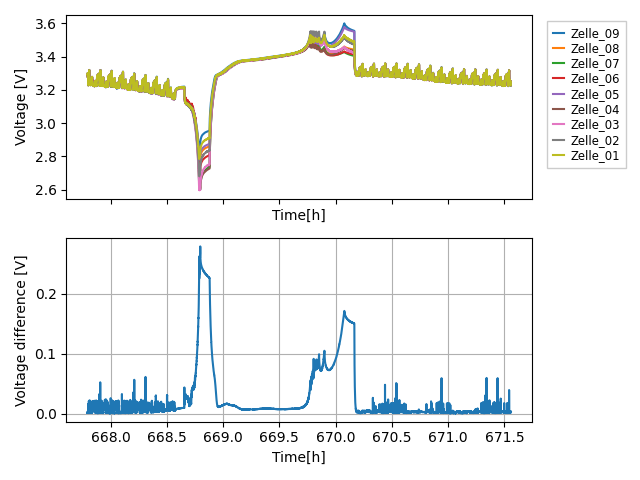

In [44]:
Compare_voltages(r"Z:\Forschung\bgA\J7045_Futavis_Modultests\Daten\2_Data_Futavis\Module\Phase 9")

In [ ]:
Compare_voltages(r'C:\30_Projects\Futavis\Testdaten\Module\Phase 4')


# <font color='#fa8072'> Compare Check Ups between two cells </font>

In [ ]:
files={}
dataset_number = []
df_List = []
cellpath = []
df_dict ={}
rootpath = r'C:\30_Projects\Futavis\Testdaten\Zellen\Zyklische Alterung\K25\CU 3'

List_Cell = glob.glob1(rootpath, '*.csv')
for cell in List_Cell:
    fullpath = rootpath + '/' + cell
    cellpath.append(fullpath)


for cell_file in cellpath:
    df_read = pd.read_csv(cell_file,sep = ',',
                          low_memory=False,
                          usecols = ['Spannung','Strom','Programmdauer'])
    df_read1 = df_read[1:]
    df_read1['Spannung']=df_read1['Spannung'].convert_dtypes().astype(float)
    df_read1['Strom']=df_read1['Strom'].convert_dtypes().astype(float)
    #df_read1['AhAkku']=df_read1['AhAkku'].convert_dtypes().astype(float)
    df_read1['Programmdauer']=df_read1['Programmdauer']/3600000
    df_read1['Name'] = cell_file.split('_')[2]

    df_List.append(df_read1.round(4))

# Shift so the first peaks overlay
df_List_shifted = []

reference = df_List[0][(df_List[0]['Spannung']>= 3.5999)].Programmdauer.index[0]
df_List_shifted.append(df_List[0])

for cell_df in df_List[1:]:
    offset = reference - cell_df[cell_df['Spannung']>=  3.5999].Programmdauer.index[0]
    mask = ~(cell_df.columns.isin(['Programmdauer','Name']))
    cols_to_shift = cell_df.columns[mask]
    cell_df[cols_to_shift] = cell_df[cols_to_shift].shift(periods=offset)

    #cell_df = cell_df.shift(periods=offset)

    df_List_shifted.append(cell_df)

# Plot
%matplotlib notebook
fig,ax = plt.subplots()

for df in df_List_shifted:
    ax.plot(df['Programmdauer'], df['Spannung'],label=df['Name'].iloc[1])

ax.set_xlabel("Time")
ax.set_ylabel("Voltage [V]")
ax.grid()
ax.legend()

plt.show()

#fig.savefig('checkup-verlauf.svg', format = 'svg', dpi=300,bbox_inches = "tight")


In [ ]:
cellpath

In [ ]:
files={}
dataset_number = []
df_List = []
path = []
df_dict ={}
rootpath = r'C:\30_Projects\Futavis\Testdaten\Zellen\Zyklische Alterung\Check-Up-01\Extremes Profil'

List_Cell = glob.glob1(rootpath, '*.csv')
for cell in List_Cell:
    fullpath = rootpath + '/' + cell
    path.append(fullpath)
    
    
    
for cell_file in path[0:1]:
    df_read = pd.read_csv(cell_file,sep = ',',
                          low_memory=False,
                          usecols = ['Spannung','AhAkku','Programmdauer'])
    df_read1 = df_read[1:]
    df_read1['Programmdauer']=df_read1['Programmdauer']/3600000
    df_read1['Spannung']=df_read1['Spannung'].convert_dtypes().astype(float)
    df_read1['AhAkku']=df_read1['AhAkku'].convert_dtypes().astype(float)
    #df_read1 = df_read1[df_read1['Spannung']<=5]
    #df_read1.loc[df_read1['AhAkku'] > 5.0, 'AhAkku'] = 0
    df_read1['Name'] = cell_file.split('_')[4].split('-')[3]+' CU1'

    df_List.append(df_read1.round(4))
    
path = []
rootpath = r'C:\30_Projects\Futavis\Testdaten\Zellen\Zyklische Alterung\Check-Up-02\Extreme Profil'

List_Cell = glob.glob1(rootpath, '*.csv')
for cell in List_Cell:
    fullpath = rootpath + '/' + cell
    path.append(fullpath)
    
    
for cell_file in path[0:1]:
    df_read = pd.read_csv(cell_file,sep = ',',
                          low_memory=False,
                          usecols = ['Spannung','AhAkku','Programmdauer'])
    df_read1 = df_read[1:]
    df_read1['Spannung']=df_read1['Spannung'].convert_dtypes().astype(float)
    df_read1['AhAkku']=df_read1['AhAkku'].convert_dtypes().astype(float)
    #df_read1 = df_read1[df_read1['Spannung']<=5]
    #df_read1.loc[df_read1['AhAkku'] > 5.0, 'AhAkku'] = 0
    df_read1['Name'] = cell_file.split('_')[4].split('-')[3]+' CU2'

    df_List.append(df_read1.round(4))
    
    
df_List_shifted = []

reference = df_List[0][(df_List[0]['Spannung']>= 3.5999)].Programmdauer.index[0]
df_List_shifted.append(df_List[0])

for cell_df in df_List[1:]:
    offset = reference - cell_df[cell_df['Spannung']>=  3.5999].Programmdauer.index[0]
    mask = ~(cell_df.columns.isin(['Programmdauer','Name']))
    cols_to_shift = cell_df.columns[mask]
    cell_df[cols_to_shift] = cell_df[cols_to_shift].shift(periods=offset)
    
    #cell_df = cell_df.shift(periods=offset)

    df_List_shifted.append(cell_df)
    
    
%matplotlib notebook
#plt.rcParams['axes.grid']=True
fig,ax = plt.subplots()

for df in df_List_shifted:
    ax.plot(df['Programmdauer'], df['Spannung'],label=df['Name'].iloc[1])
#ax.plot(df_read['Programmdauer'], df_read['AhAkku'])
#ax1= ax.twinx()
#ax1.plot(df_read['Programmdauer'], df_read['AhAkku'],color='orange',label='Ampere-hour')

ax.set_xlabel("Time")
ax.set_ylabel("Voltage [V]")
#ax1.set_ylabel("Ampere-hour count [Ah]")

#ax.set_xlim([7e7, 8e7])
#ax.set_xlim([0, 5e6])
ax.grid()
ax.legend()
#ax1.legend()

plt.show()

#fig.savefig('checkup-verlauf.svg', format = 'svg', dpi=300,bbox_inches = "tight")


# <font color='#fa8072'> Compare cycle between two cells </font>

In [ ]:
Compare_cycle(r'C:\30_Projects\Futavis\Testdaten\Zellen\Zyklische Alterung\K45\Alterungszyklus 2')

In [ ]:
df_List[0][df_List[0]['Spannung']>=  3.599999].Programmdauer.index[0]

In [ ]:
df_List[1][df_List[1]['Spannung']>=  3.599999].Programmdauer.index[0]

In [ ]:
files={}
dataset_number = []
df_List = []
path = []
df_dict ={}
rootpath = r'C:\30_Projects\Futavis\Testdaten\Zellen\Zyklische Alterung\K25\Phase 1'

List_Cell = glob.glob1(rootpath, '*.csv')
for cell in List_Cell[0:1]:
    fullpath = rootpath + '/' + cell
    path.append(fullpath)
    
    
for cell_file in path:
    df_read = pd.read_csv(cell_file,sep = ',',
                          low_memory=False,
                          usecols = ['Spannung','AhAkku','Programmdauer'])
    df_read1 = df_read[1:]
    df_read1['Spannung']=df_read1['Spannung'].convert_dtypes().astype(float)
    df_read1['AhAkku']=df_read1['AhAkku'].convert_dtypes().astype(float)
    #df_read1 = df_read1[df_read1['Spannung']<=5]
    #df_read1.loc[df_read1['AhAkku'] > 5.0, 'AhAkku'] = 0
    df_read1['Name'] = cell_file.split('_')[2]+' Cycle 1'

    df_List.append(df_read1.round(4))
    
path = []
rootpath = r'C:\30_Projects\Futavis\Testdaten\Zellen\Zyklische Alterung\K45\Phase 1'

List_Cell = glob.glob1(rootpath, '*.csv')

for cell in List_Cell[0:1]:
    fullpath = rootpath + '/' + cell
    path.append(fullpath)
    
for cell_file in path:
    df_read = pd.read_csv(cell_file,sep = ',',
                          low_memory=False,
                          usecols = ['Spannung','AhAkku','Programmdauer'])
    df_read1 = df_read[1:]
    df_read1['Spannung']=df_read1['Spannung'].convert_dtypes().astype(float)
    df_read1['AhAkku']=df_read1['AhAkku'].convert_dtypes().astype(float)
    #df_read1 = df_read1[df_read1['Spannung']<=5]
    #df_read1.loc[df_read1['AhAkku'] > 5.0, 'AhAkku'] = 0
    df_read1['Name'] = cell_file.split('_')[2]+' Cycle 2'

    df_List.append(df_read1.round(4))
    
    
df_List_shifted = []

reference = df_List[0][(df_List[0]['Spannung']>= 3.599999)].Programmdauer.index[0]
df_List_shifted.append(df_List[0])

for cell_df in df_List[1:]:
    offset = reference - cell_df[cell_df['Spannung']>=  3.599999].Programmdauer.index[0]
    mask = ~(cell_df.columns.isin(['Programmdauer','Name']))
    cols_to_shift = cell_df.columns[mask]
    cell_df[cols_to_shift] = cell_df[cols_to_shift].shift(periods=offset)
    
    #cell_df = cell_df.shift(periods=offset)

    df_List_shifted.append(cell_df)
    
    
%matplotlib notebook
#plt.rcParams['axes.grid']=True
fig,ax = plt.subplots()

for df in df_List_shifted:
    ax.plot(df['Programmdauer'], df['Spannung'],label=df['Name'].iloc[1])
#ax.plot(df_read['Programmdauer'], df_read['AhAkku'])
#ax1= ax.twinx()
#ax1.plot(df_read['Programmdauer'], df_read['AhAkku'],color='orange',label='Ampere-hour')

ax.set_xlabel("Time")
ax.set_ylabel("Voltage [V]")
#ax1.set_ylabel("Ampere-hour count [Ah]")

#ax.set_xlim([7e7, 8e7])
ax.set_xlim([0, 5e7])
ax.grid()
ax.legend()
#ax1.legend()

plt.show()

#fig.savefig('checkup-verlauf.svg', format = 'svg', dpi=300,bbox_inches = "tight")


In [ ]:
os.path.splitext(fullpath)[1]

In [ ]:
files={}
dataset_number = []
df_List = []
path = []
df_dict ={}
rootpath = r'C:\30_Projects\Futavis\Testdaten\Zellen\Zyklische Alterung\Phase-01\Extremes Profil'

List_Cell = glob.glob1(rootpath, '*.csv')
for cell in List_Cell:
    fullpath = rootpath + '/' + cell
    rename = '='.join(os.path.splitext(fullpath)[0].split('=')[:2])
    os.rename(fullpath, rename + os.path.splitext(fullpath)[1])
    fullpath='='.join(fullpath.split('=')[:2])+'.csv'
    path.append(fullpath)
    

In [ ]:
%matplotlib notebook
#plt.rcParams['axes.grid']=True
fig,ax = plt.subplots()

for df in df_List_shifted:
    ax.plot(df['Programmdauer'], df['Spannung'],label=df['Name'].iloc[1])
#ax.plot(df_read['Programmdauer'], df_read['AhAkku'])
#ax1= ax.twinx()
#ax1.plot(df_read['Programmdauer'], df_read['AhAkku'],color='orange',label='Ampere-hour')

ax.set_xlabel("Time")
ax.set_ylabel("Voltage [V]")
#ax1.set_ylabel("Ampere-hour count [Ah]")

#ax.set_xlim([7e7, 8e7])
#ax.set_xlim([0, 5e6])
ax.grid()
ax.legend()
#ax1.legend()

plt.show()

fig.savefig('checkup-verlauf.svg', format = 'svg', dpi=300,bbox_inches = "tight")


In [ ]:
df_read = pd.read_csv(r'C:\30_Projects\Futavis\Auswertung\J7045_Futavis_Modultests_Zelltests=DDO-FUTAVIS-CELL-NR10-LFP-50AH=Check-Up-02=Zyklische Alterung Zellen=2024-01-09 162911=ddo_Futavis_Zelle_periodischerTest_25C_CAN_ID_0=TS209708  Format01=Kreis 6-010.csv',
                                sep = ',',
                                usecols = ['Spannung','AhAkku','Programmdauer'])

df_read1 = df_read[1:]
df_read1['Spannung']=df_read1['Spannung'].convert_dtypes().astype(float)
df_read1['AhAkku']=df_read1['AhAkku'].convert_dtypes().astype(float)
df_read1 = df_read1[df_read1['Spannung']<=5]
df_read1.loc[df_read1['AhAkku'] > 5.0, 'AhAkku'] = 0

df_read = pd.read_csv(r'C:\Users\zho\Downloads\J3661_BMBF_OptiPro=Module_35E_2_OLD=Balanced SOC-reconditioned=Module Tests =2023-08-01 181610=zho_EIS_Cell2=EIS00005  Format01=EISkanal 26-2.csv',
                                sep = ',',
                                usecols = ['Spannung','AhAkku','Programmdauer'])

df_read2 = df_read[1:]
df_read2['Spannung']=df_read2['Spannung'].convert_dtypes().astype(float)
df_read2['AhAkku']=df_read2['AhAkku'].convert_dtypes().astype(float)
df_read2.Programmdauer=df_read2.Programmdauer+19723324.0
df_read2.loc[df_read2['AhAkku'] > 5.0, 'AhAkku'] = 0




df_read=pd.concat([df_read1,df_read2])